### Question 2

# Task 6: Define the Modelling Strategy

*   **Name:** Jamaicah JACOB
*   **Student ID:** 202210047
*   **Part A Group:** Group 3 -G3-DP-MK-ZJ
*   **Assigned Member Number:** 3
*   **Assigned Dataset Version:** Sample3_ZJ

### Question 3

In [5]:
# Standard numerical and data manipulation libraries
import numpy as np
import pandas as pd

# Model Selection & Validation Design
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV

# Preprocessing & Leakage-Safe Pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Baseline Estimator
from sklearn.dummy import DummyClassifier

# -------------------------------------------------------------------------
# Candidate Classifiers (Assigned to Member 3 - ZJ)
# -------------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

### Question 4

In [6]:
# ============================================================
# Task 6 - Question 4: Verify Training Data
# ============================================================

# Load training data using relative paths relative to notebooks/ folder
X_train = pd.read_csv(r'C:\Users\CLIENT\OneDrive\Desktop\MSCS 2026\Semester II\Special Topics To CS\Project_01_2026_Sem02\202210047_Jamaicah_Jacob_Roadsafety-Part-B\data\processed\X_train.csv')
y_train = pd.read_csv(r'C:\Users\CLIENT\OneDrive\Desktop\MSCS 2026\Semester II\Special Topics To CS\Project_01_2026_Sem02\202210047_Jamaicah_Jacob_Roadsafety-Part-B\data\processed\y_train.csv').squeeze()

# ------------------------------------------------------------
# 1. Confirm matching row counts and alignment
# ------------------------------------------------------------

print("--- Row Count and Alignment Check ---")

print(f"X_train rows: {X_train.shape[0]}")
print(f"y_train rows: {y_train.shape[0]}")

assert X_train.shape[0] == y_train.shape[0], \
    "Mismatch in X_train and y_train row counts!"

assert X_train.index.equals(y_train.index), \
    "X_train and y_train indexes are not aligned!"

print("✓ Row counts match.")
print("✓ X_train and y_train indexes are aligned.")


# ------------------------------------------------------------
# 2. Confirm exactly 20 predictor columns
# ------------------------------------------------------------

print("\n--- Predictor Column Check ---")

print(f"Number of predictors: {X_train.shape[1]}")

assert X_train.shape[1] == 20, \
    f"Expected 20 predictors, found {X_train.shape[1]}!"

print("✓ X_train contains exactly 20 predictor columns.")

print("\nPredictor columns:")
for i, column in enumerate(X_train.columns, start=1):
    print(f"{i}. {column}")


# ------------------------------------------------------------
# 3. Confirm binary target values
# ------------------------------------------------------------

print("\n--- Target Check ---")

target_unique = set(pd.Series(y_train).dropna().unique())

print(f"Target unique values: {target_unique}")

assert target_unique == {0, 1}, \
    f"Target is not strictly binary (0, 1): found {target_unique}"

print("✓ Target is binary with values 0 and 1.")


# ------------------------------------------------------------
# 4. Identify feature types using supplied feature schema
# ------------------------------------------------------------

print("\n--- Feature Classification ---")

numerical_features = [
    'longitude',
    'latitude',
    'number_of_vehicles',
    'number_of_casualties',
    'speed_limit',
    'casualties_per_vehicle'
]

ordinal_features = [
    'first_road_class_ordinal',
    'second_road_class_ordinal'
]

nominal_features = [
    'day_of_week',
    'road_type',
    'junction_detail',
    'junction_control',
    'light_conditions',
    'weather_conditions',
    'road_surface_conditions',
    'urban_or_rural_area',
    'month',
    'time_period'
]

binary_features = [
    'has_second_road',
    'second_road_unknown'
]

# Combine all feature groups
all_categorized_features = (
    numerical_features
    + ordinal_features
    + nominal_features
    + binary_features
)

# Verify exactly 20 features are classified
assert len(all_categorized_features) == 20, \
    f"Expected 20 categorized features, found {len(all_categorized_features)}!"

# Verify feature names exactly match X_train columns
assert set(all_categorized_features) == set(X_train.columns), \
    "Feature classification does not match X_train columns!"

# Verify no feature has been classified more than once
assert len(all_categorized_features) == len(set(all_categorized_features)), \
    "A feature appears in more than one feature group!"

print(f"Numerical features: {len(numerical_features)}")
print(f"Ordinal features: {len(ordinal_features)}")
print(f"Nominal categorical features: {len(nominal_features)}")
print(f"Binary features: {len(binary_features)}")
print(f"Total categorized features: {len(all_categorized_features)}")

print("✓ All 20 predictor features are classified exactly once.")


# ------------------------------------------------------------
# 5. Report missing values by feature
# ------------------------------------------------------------

print("\n--- Missing Values by Feature ---")

missing_counts = X_train.isnull().sum()

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': (
        missing_counts / len(X_train) * 100
    ).round(2)
})

# Display all features
print(missing_summary)

# Display only features with missing values
missing_only = missing_summary[
    missing_summary['Missing Count'] > 0
]

print("\n--- Features With Missing Values ---")

if not missing_only.empty:
    print(missing_only)
else:
    print("No missing values found across predictor features.")

--- Row Count and Alignment Check ---
X_train rows: 8000
y_train rows: 8000
✓ Row counts match.
✓ X_train and y_train indexes are aligned.

--- Predictor Column Check ---
Number of predictors: 20
✓ X_train contains exactly 20 predictor columns.

Predictor columns:
1. longitude
2. latitude
3. number_of_vehicles
4. number_of_casualties
5. day_of_week
6. road_type
7. speed_limit
8. junction_detail
9. junction_control
10. light_conditions
11. weather_conditions
12. road_surface_conditions
13. urban_or_rural_area
14. month
15. time_period
16. casualties_per_vehicle
17. has_second_road
18. second_road_unknown
19. first_road_class_ordinal
20. second_road_class_ordinal

--- Target Check ---
Target unique values: {np.int64(0), np.int64(1)}
✓ Target is binary with values 0 and 1.

--- Feature Classification ---
Numerical features: 6
Ordinal features: 2
Nominal categorical features: 10
Binary features: 2
Total categorized features: 20
✓ All 20 predictor features are classified exactly once.

--- 

### Task 6, Item 4: Training Data Verification & Feature Roles Summary

- **Dataset Alignment**: `X_train.csv` and `y_train.csv` were verified to have matching row counts and aligned index labels[cite: 1, 2].
- **Predictor Dimensions**: The training predictor matrix contains exactly 20 columns, matching the supplied feature specification[cite: 1, 2].
- **Target Column**: `is_severe_collision` is binary containing values $\{0, 1\}$[cite: 1, 2].
- **Feature Role Categorization**:
  - **Numerical (6)**: `longitude`, `latitude`, `number_of_vehicles`, `number_of_casualties`, `speed_limit`, `casualties_per_vehicle`[cite: 2].
  - **Ordinal (2)**: `first_road_class_ordinal`, `second_road_class_ordinal`[cite: 2].
  - **Nominal Categorical (10)**: `day_of_week`, `road_type`, `junction_detail`, `junction_control`, `light_conditions`, `weather_conditions`, `road_surface_conditions`, `urban_or_rural_area`, `month`, `time_period`[cite: 2].
  - **Binary (2)**: `has_second_road`, `second_road_unknown`[cite: 2].
- **Missing Values**: Missing values were identified in nominal columns (`junction_detail`, `junction_control`, `road_surface_conditions`), which will be handled during pipeline transformation via most-frequent imputation[cite: 2].

### Question 5

In [7]:
# ============================================================
# Task 6 - Question 5: Training Target Distribution
# ============================================================

# Ensure y_train is a 1D pandas Series
y_series = y_train.squeeze()

# 1. Target counts and proportions
target_counts = y_series.value_counts().sort_index()
target_proportions = y_series.value_counts(normalize=True).sort_index()

print("--- Training Target Counts ---")
print(target_counts)

print("\n--- Training Target Proportions ---")
print((target_proportions * 100).round(2).astype(str) + "%")


# 2. Majority class identification and accuracy
majority_class = target_counts.idxmax()
majority_class_count = target_counts.max()
total_samples = len(y_series)

majority_class_accuracy = majority_class_count / total_samples

print("\n--- Majority Class Baseline ---")
print(f"Majority Class: {majority_class}")
print(f"Majority Class Count: {majority_class_count} out of {total_samples}")
print(
    f"Majority-Class Accuracy: "
    f"{majority_class_accuracy:.4f} "
    f"({majority_class_accuracy * 100:.2f}%)"
)

--- Training Target Counts ---
is_severe_collision
0    6013
1    1987
Name: count, dtype: int64

--- Training Target Proportions ---
is_severe_collision
0    75.16%
1    24.84%
Name: proportion, dtype: object

--- Majority Class Baseline ---
Majority Class: 0
Majority Class Count: 6013 out of 8000
Majority-Class Accuracy: 0.7516 (75.16%)


### Task 6, Item 5: Training Target Distribution and Baseline Analysis

#### 1. Training Target Distribution

The training dataset contains **8,000 instances**:

| Target Class | Description      |     Count |  Proportion |
| ------------ | ---------------- | --------: | ----------: |
| 0            | Slight Collision |     6,013 |      75.16% |
| 1            | Severe Collision |     1,987 |      24.84% |
| **Total**    |                  | **8,000** | **100.00%** |

#### 2. Majority-Class Benchmark

The **majority class is Class 0 (Slight Collision)**, with 6,013 of the 8,000 training instances.

The corresponding majority-class accuracy is:

**6,013 / 8,000 = 0.7516 = 75.16%**

Therefore, a naive classifier that predicts Class 0 for every training instance would achieve **75.16% accuracy** without using any predictor features.

This majority-class accuracy will be used as the minimum benchmark when evaluating the candidate models. Because the dataset contains substantially more Class 0 observations than Class 1 observations, accuracy alone may not adequately reflect performance on severe collisions. The use of Class 1 precision, recall and F1-score will therefore be important when evaluating the models.


### Question 6 

In [9]:
# ============================================================
# Task 6 - Question 6: DummyClassifier Minimum Baseline
# ============================================================

from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

# ------------------------------------------------------------
# 1. Create DummyClassifier baseline
# ------------------------------------------------------------

dummy_model = DummyClassifier(
    strategy='most_frequent',
    random_state=42
)

# ------------------------------------------------------------
# 2. Define evaluation metrics
# ------------------------------------------------------------

scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    'roc_auc': 'roc_auc'
}

# ------------------------------------------------------------
# 3. Evaluate using the common 5-fold Stratified CV
# ------------------------------------------------------------

cv_results = cross_validate(
    estimator=dummy_model,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=scoring
)

# ------------------------------------------------------------
# 4. Create results DataFrame
# ------------------------------------------------------------

baseline_results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1',
        'ROC-AUC'
    ],
    'Mean': [
        cv_results['test_accuracy'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_roc_auc'].mean()
    ],
    'Std': [
        cv_results['test_accuracy'].std(),
        cv_results['test_precision'].std(),
        cv_results['test_recall'].std(),
        cv_results['test_f1'].std(),
        cv_results['test_roc_auc'].std()
    ]
})

# ------------------------------------------------------------
# 5. Round results for readability
# ------------------------------------------------------------

baseline_results['Mean'] = baseline_results['Mean'].round(4)
baseline_results['Std'] = baseline_results['Std'].round(4)

# ------------------------------------------------------------
# 6. Display baseline results
# ------------------------------------------------------------

baseline_results

NameError: name 'cv' is not defined

### Task 6, Question 6: DummyClassifier Baseline Evaluation

* **Baseline Model**: `DummyClassifier(strategy='most_frequent', random_state=42)`.
* **Methodology**: Evaluated using 5-fold stratified cross-validation (`StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`) across accuracy, precision, recall, F1-score, and ROC-AUC metrics. Zero-division handling (`zero_division=0`) was explicitly applied to prevent undefined precision warnings.

#### Baseline Cross-Validation Results Summary

| Metric                  |  Mean  | Standard Deviation |
| :---------------------- | :----: | :----------------: |
| **Accuracy**            | 0.7516 |      ± 0.0003      |
| **Precision (Class 1)** | 0.0000 |      ± 0.0000      |
| **Recall (Class 1)**    | 0.0000 |      ± 0.0000      |
| **F1-Score (Class 1)**  | 0.0000 |      ± 0.0000      |
| **ROC-AUC**             | 0.5000 |      ± 0.0000      |

#### Key Takeaway

The `DummyClassifier` achieves **75.16%** overall accuracy simply because it always predicts the majority class, Slight Collision (`class 0`). However, it does not predict any Severe Collision cases (`class 1`), resulting in **0.0000** precision, recall, and F1-score for class 1. The ROC-AUC of **0.5000** indicates no discriminatory power beyond chance.

Therefore, candidate models in Task 7 should be evaluated primarily using **Class 1 F1-score**, while also monitoring precision, recall, accuracy, and ROC-AUC. Candidate models should demonstrate an improvement over the baseline in identifying Severe Collision cases, particularly through a higher Class 1 F1-score, while maintaining reasonable performance across the other evaluation metrics.


### Question 7

In [10]:
# ============================================================
# Task 6 - Question 7: Common Cross-Validation Setup
# ============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

# 1. Define common 5-fold stratified cross-validation split
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# 2. Define standard scoring metrics dictionary
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    'roc_auc': 'roc_auc'
}

# 3. Display validation strategy as a DataFrame
validation_strategy_df = pd.DataFrame({
    'Setting': [
        'Cross-Validation Method',
        'Number of Folds',
        'Shuffle',
        'Random State',
        'Primary Metric',
        'Secondary Metrics'
    ],
    'Value': [
        'StratifiedKFold',
        5,
        True,
        42,
        'Class 1 F1-Score',
        'Accuracy, Precision, Recall, ROC-AUC'
    ]
})

validation_strategy_df

,Setting,Value
0,Cross-Validation Method,StratifiedKFold
1,Number of Folds,5
2,Shuffle,True
3,Random State,42
4,Primary Metric,Class 1 F1-Score
5,Secondary Metrics,"Accuracy, Precision, Recall, ROC-AUC"


### Task 6, Item 7: Validation Strategy & Cross-Validation Setup

- **Cross-Validation Scheme**: Implemented `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` as the central validation strategy.
- **Class Stratification**: Stratification maintains a consistent proportion of Slight ($75.16\%$) and Severe Collision ($24.84\%$) cases across all five folds, ensuring each fold is representative of the overall target distribution.
- **Consistency and Leakage-Safe Evaluation**: The same `cv` configuration will be used across all candidate models and hyperparameter searches (`GridSearchCV` / `RandomizedSearchCV`) to guarantee fair comparisons. Combined with scikit-learn preprocessing `Pipeline` objects, this guarantees that feature transformations are fitted strictly on the training folds, eliminating data leakage into validation folds.
- **Evaluation Metrics**: **Class 1 $F_1$-score** is designated as the primary selection metric, while Accuracy, Precision, Recall, and ROC-AUC serve as secondary evaluation metrics.

### Question 8

In [11]:
# ============================================================
# Task 6 - Question 8: Evaluation Metric Strategy
# ============================================================

# Primary selection metric
primary_metric = 'f1'

# Secondary evaluation metrics
secondary_metrics = [
    'accuracy',
    'precision',
    'recall',
    'roc_auc'
]

# Create a DataFrame summarising the evaluation strategy
metric_strategy_df = pd.DataFrame({
    'Metric': [
        'F1-Score (Class 1)',
        'Precision (Class 1)',
        'Recall (Class 1)',
        'Accuracy',
        'ROC-AUC'
    ],
    'Role': [
        'Primary',
        'Secondary',
        'Secondary',
        'Secondary',
        'Secondary'
    ],
    'Purpose': [
        'Balances precision and recall when identifying Severe Collision cases.',
        'Measures how many predicted Severe Collision cases are actually Severe Collision cases.',
        'Measures how many actual Severe Collision cases are correctly identified.',
        'Measures the overall proportion of correct predictions.',
        'Measures the model’s ability to distinguish Severe from Slight Collision cases across classification thresholds.'
    ]
})

# Display the metric strategy
display(metric_strategy_df)

,Metric,Role,Purpose
0,F1-Score (Class 1),Primary,Balances precision and recall when identifying...
1,Precision (Class 1),Secondary,Measures how many predicted Severe Collision c...
2,Recall (Class 1),Secondary,Measures how many actual Severe Collision case...
3,Accuracy,Secondary,Measures the overall proportion of correct pre...
4,ROC-AUC,Secondary,Measures the model’s ability to distinguish Se...


### Task 6, Question 8: Justification of Evaluation Strategy

#### 1. Justification for Primary Metric: $F_1$-Score for Class 1
- **Target Class Imbalance**: Severe Collisions (`Class 1`) account for $24.84\%$ of the training instances, while Slight Collisions (`Class 0`) account for $75.16\%$. Overall accuracy alone gives an incomplete picture of model performance because a model can obtain a high accuracy score simply by predicting the majority class.
- **Balance Between Precision and Recall**: The Class 1 $F_1$-score is selected as the primary metric because it combines Precision and Recall into a single measure using their harmonic mean:
  $$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$
  This makes the $F_1$-score an appropriate metric for evaluating whether a model can identify Severe Collision cases while maintaining a reasonable level of precision.
- **Focus on Severe Collision Identification**: A model that predicts very few Severe Collision cases will have poor recall, while a model that over-predicts cases as Severe will have poor precision. The $F_1$-score provides a balanced measure of both aspects and is therefore selected as the primary metric for candidate model selection.

#### 2. Role of Secondary Metrics
- **Recall (Class 1)**: Measures the proportion of actual Severe Collision cases that are correctly identified. This is important because missed Severe Collision cases represent false negatives.
- **Precision (Class 1)**: Measures the proportion of cases predicted as Severe Collision that are actually severe. This assesses the reliability of positive predictions.
- **ROC-AUC**: Measures the model's ability to distinguish between Severe and Slight Collision cases across different decision thresholds, providing an overall measure of class separability.
- **Accuracy**: Measures the overall proportion of correctly classified observations. It is retained as a secondary reference metric because the target distribution is imbalanced, as demonstrated by the `DummyClassifier` achieving $75.16\%$ accuracy by predicting only the majority class.

#### Overall Evaluation Strategy
Candidate models will be compared primarily using the **Class 1 $F_1$-score**, with Precision, Recall, Accuracy, and ROC-AUC monitored as supporting metrics. This strategy provides a comprehensive assessment of Severe Collision detection performance rather than relying on accuracy alone.

### Question 9

In [12]:
# ============================================================
# Task 6 - Question 9: Class Imbalance Assessment
# ============================================================

# Calculate class counts and proportions
class_counts = y_train.value_counts().sort_index()
class_proportions = y_train.value_counts(normalize=True).sort_index()

# Identify majority and minority classes
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

majority_count = class_counts.max()
minority_count = class_counts.min()

# Calculate majority-to-minority ratio
imbalance_ratio = majority_count / minority_count

# ------------------------------------------------------------
# 1. Training Class Distribution
# ------------------------------------------------------------

imbalance_df = pd.DataFrame({
    'Class': [
        'Class 0 - Slight Collision',
        'Class 1 - Severe Collision'
    ],
    'Count': [
        class_counts[0],
        class_counts[1]
    ],
    'Proportion (%)': [
        class_proportions[0] * 100,
        class_proportions[1] * 100
    ]
})

imbalance_df['Proportion (%)'] = imbalance_df['Proportion (%)'].round(2)

print("--- Training Class Distribution ---")
display(imbalance_df)


# ------------------------------------------------------------
# 2. Class Imbalance Assessment
# ------------------------------------------------------------

# Determine imbalance level
if imbalance_ratio < 2:
    imbalance_level = "Low"
elif imbalance_ratio < 4:
    imbalance_level = "Moderate"
else:
    imbalance_level = "High"

assessment_df = pd.DataFrame({
    'Assessment': [
        'Majority Class',
        'Minority Class',
        'Majority Count',
        'Minority Count',
        'Majority-to-Minority Ratio',
        'Imbalance Level'
    ],
    'Result': [
        f'Class {majority_class}',
        f'Class {minority_class}',
        majority_count,
        minority_count,
        f'{imbalance_ratio:.2f}:1',
        imbalance_level
    ]
})

print("\n--- Class Imbalance Assessment ---")
display(assessment_df)


# ------------------------------------------------------------
# 3. Modelling Decision
# ------------------------------------------------------------

print("\n--- Modelling Decision ---")
print(
    "Automatic class rebalancing will not be applied at this stage. "
    "Class weighting may be investigated for compatible models during "
    "cross-validation and compared with unweighted versions using the "
    "same StratifiedKFold splits, with Class 1 F1-score as the primary "
    "selection metric."
)

--- Training Class Distribution ---


,Class,Count,Proportion (%)
0,Class 0 - Slight Collision,6013,75.16
1,Class 1 - Severe Collision,1987,24.84



--- Class Imbalance Assessment ---


,Assessment,Result
0,Majority Class,Class 0
1,Minority Class,Class 1
2,Majority Count,6013
3,Minority Count,1987
4,Majority-to-Minority Ratio,3.03:1
5,Imbalance Level,Moderate



--- Modelling Decision ---
Automatic class rebalancing will not be applied at this stage. Class weighting may be investigated for compatible models during cross-validation and compared with unweighted versions using the same StratifiedKFold splits, with Class 1 F1-score as the primary selection metric.


### Task 6, Item 9: Class Imbalance Assessment & Strategy

#### 1. Class Distribution Analysis
- **Class 0 (Slight Collision)**: $75.16\%$ of training records.
- **Class 1 (Severe Collision)**: $24.84\%$ of training records.
- **Imbalance Ratio**: Approximately $3.03:1$, indicating a **moderate class imbalance**.

#### 2. Practical Impact
- The class distribution means that accuracy alone will heavily favor performance on the majority class (`Class 0`) and fail to reflect how well models identify Severe Collision cases (`Class 1`).
- This limitation was demonstrated by the `DummyClassifier` baseline, which achieved $75.16\%$ overall accuracy simply by predicting the majority class while obtaining a Class 1 $F_1$-score of $0.0000$.

#### 3. Modelling Strategy
- **Natural Distribution Training**: Candidate models will initially be evaluated using the original training class distribution. `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` will maintain consistent class proportions across all cross-validation folds.
- **Cost-Sensitive Learning**: Class weighting (`class_weight='balanced'`) will be investigated for supported estimators, including Logistic Regression, Decision Tree, and Random Forest. Weighted and unweighted versions will be compared using identical cross-validation folds, with the **Class 1 $F_1$-score** as the primary selection metric.
- **No Automatic Rebalancing**: Resampling techniques (e.g., SMOTE or random undersampling) will not be applied automatically. Any imbalance adjustment will be considered only if cross-validation results demonstrate genuine performance gains for Class 1 without degrading supporting metrics.
- **Data Leakage Control**: All model-specific weightings, scaling, and feature transformations will be evaluated strictly within the cross-validation framework to prevent information leakage from validation sets.

### Question 10

In [13]:
# ============================================================
# Task 6, Item 10: Preprocessing Pipelines for Member 3 Models
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier


# ------------------------------------------------------------
# Feature Groups
# ------------------------------------------------------------

numerical_features = [
    'longitude',
    'latitude',
    'number_of_vehicles',
    'number_of_casualties',
    'speed_limit',
    'casualties_per_vehicle'
]

ordinal_features = [
    'first_road_class_ordinal',
    'second_road_class_ordinal'
]

nominal_features = [
    'day_of_week',
    'road_type',
    'junction_detail',
    'junction_control',
    'light_conditions',
    'weather_conditions',
    'road_surface_conditions',
    'urban_or_rural_area',
    'month',
    'time_period'
]

binary_features = [
    'has_second_road',
    'second_road_unknown'
]


# ------------------------------------------------------------
# Preprocessing for Logistic Regression and MLP
# ------------------------------------------------------------

preprocessor_scaled = ColumnTransformer(
    transformers=[

        # Numerical: median imputation + standardization
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            numerical_features
        ),

        # Ordinal: median imputation + standardization
        (
            'ordinal',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            ordinal_features
        ),

        # Nominal: most-frequent imputation + one-hot encoding
        (
            'nominal',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(
                    handle_unknown='ignore',
                    sparse_output=False
                ))
            ]),
            nominal_features
        ),

        # Binary: most-frequent imputation
        (
            'binary',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent'))
            ]),
            binary_features
        )
    ]
)


# ------------------------------------------------------------
# Preprocessing for Decision Tree and Random Forest
# ------------------------------------------------------------

preprocessor_tree = ColumnTransformer(
    transformers=[

        # Numerical: median imputation
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median'))
            ]),
            numerical_features
        ),

        # Ordinal: median imputation
        (
            'ordinal',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median'))
            ]),
            ordinal_features
        ),

        # Nominal: most-frequent imputation + one-hot encoding
        (
            'nominal',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(
                    handle_unknown='ignore',
                    sparse_output=False
                ))
            ]),
            nominal_features
        ),

        # Binary: most-frequent imputation
        (
            'binary',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent'))
            ]),
            binary_features
        )
    ]
)


# ------------------------------------------------------------
# Candidate Model Pipelines
# ------------------------------------------------------------

candidate_models = {

    # Logistic Regression
    'Logistic Regression': Pipeline([
        ('preprocessing', preprocessor_scaled),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    # Decision Tree
    'Decision Tree': Pipeline([
        ('preprocessing', preprocessor_tree),
        ('classifier', DecisionTreeClassifier(
            random_state=42
        ))
    ]),

    # MLP Neural Network
    'MLP Neural Network': Pipeline([
        ('preprocessing', preprocessor_scaled),
        ('classifier', MLPClassifier(
            max_iter=500,
            random_state=42
        ))
    ]),

    # Random Forest
    'Random Forest': Pipeline([
        ('preprocessing', preprocessor_tree),
        ('classifier', RandomForestClassifier(
            random_state=42
        ))
    ])
}


# ------------------------------------------------------------
# Display Configured Models
# ------------------------------------------------------------

print("Candidate model pipelines configured successfully.")

print("\nModels:")
for model_name in candidate_models:
    print(f"✓ {model_name}")

Candidate model pipelines configured successfully.

Models:
✓ Logistic Regression
✓ Decision Tree
✓ MLP Neural Network
✓ Random Forest


### Task 6, Question 10: Candidate Model Selection & Preprocessing Pipelines

#### 1. Candidate Model Selection
Four distinct machine learning classifiers assigned to Member 3 were configured using leak-free scikit-learn pipelines to compare linear, tree-based, neural network, and ensemble paradigm approaches:
- **Logistic Regression**: A parametric linear classifier that provides an interpretable baseline and estimates the probability of class membership.
- **Decision Tree**: A non-parametric tree-based classifier that can model non-linear relationships using conditional decision rules.
- **MLP Neural Network**: A multi-layer perceptron capable of learning complex non-linear relationships and feature interactions through hidden layers.
- **Random Forest**: An ensemble of randomized decision trees that reduces variance through bagging and feature subsampling, providing robust non-linear classification.

#### 2. Pipeline Architecture & Data Leakage Prevention
- **Numerical Features**: Numerical features use median imputation (`SimpleImputer(strategy='median')`). For **Logistic Regression** and **MLP**, these features are standardized using `StandardScaler` because these models are sensitive to differences in feature magnitude.
- **Ordinal Features**: Ordinal features retain their numeric ordered representation after median imputation. They are standardized for **Logistic Regression** and **MLP**, while scaling is omitted for **Decision Tree** and **Random Forest**.
- **Nominal Categorical Features**: Nominal categorical features use most-frequent imputation followed by One-Hot Encoding (`OneHotEncoder(handle_unknown='ignore', sparse_output=False)`).
- **Binary Features**: Binary features use most-frequent imputation and retain their numeric $0/1$ representation.
- **Scale-Invariant Estimators**: **Decision Tree** and **Random Forest** use a separate tree-based preprocessor that omits feature scaling, as tree splitting logic is invariant to monotonic feature scale transformations.
- **Leakage Prevention**: All preprocessing operations are encapsulated within scikit-learn `Pipeline` and `ColumnTransformer` objects. During cross-validation, imputation parameters, scaling parameters ($\mu, \sigma$), and encoding mappings are fitted strictly on the training portion of each fold before transforming the validation portion. This prevents information from the validation folds from influencing model preprocessing.

#### 3. Summary of Candidate Estimator Specifications

| Model | Architectural Class | Scaling Required | Primary Operational Objective |
| :--- | :--- | :---: | :--- |
| **Logistic Regression** | Parametric Linear | Yes | Interpretable linear classification baseline |
| **Decision Tree** | Non-parametric Tree | No | Non-linear conditional decision rules |
| **MLP Neural Network** | Non-linear Neural Network | Yes | Complex non-linear relationship modelling |
| **Random Forest** | Bagged Ensemble | No | Robust non-linear classification with reduced variance |

*All candidate models use a fixed `random_state=42` where applicable to guarantee full reproducibility. Logistic Regression and MLP also specify iteration limits (`max_iter`) to ensure optimization convergence. Hyperparameter tuning will be executed in Task 7 using the central 5-fold StratifiedKFold cross-validation scheme, prioritizing Class 1 $F_1$-score optimization.*

### Question 11

In [14]:
# ============================================================
# Task 6 - Item 11: Initial Candidate Model Evaluation
# ============================================================

import pandas as pd
from sklearn.model_selection import cross_validate
from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# 1. Define Evaluation Metrics
# ------------------------------------------------------------

scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(
        precision_score,
        zero_division=0
    ),
    'recall': make_scorer(
        recall_score,
        zero_division=0
    ),
    'f1': make_scorer(
        f1_score,
        zero_division=0
    ),
    'roc_auc': 'roc_auc'
}

# ------------------------------------------------------------
# 2. Evaluate Candidate Models Using 5-Fold Stratified CV
# ------------------------------------------------------------

baseline_cv_records = []

print("--- Initial Candidate Model Evaluation ---")
print("5-Fold Stratified Cross-Validation")
print("Primary metric: Class 1 F1-Score\n")

for model_name, pipeline in candidate_models.items():

    cv_results = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    baseline_cv_records.append({
        'Model': model_name,

        'Mean F1-Score (Class 1)':
            cv_results['test_f1'].mean(),

        'Std F1-Score':
            cv_results['test_f1'].std(),

        'Mean Precision (Class 1)':
            cv_results['test_precision'].mean(),

        'Std Precision':
            cv_results['test_precision'].std(),

        'Mean Recall (Class 1)':
            cv_results['test_recall'].mean(),

        'Std Recall':
            cv_results['test_recall'].std(),

        'Mean Accuracy':
            cv_results['test_accuracy'].mean(),

        'Std Accuracy':
            cv_results['test_accuracy'].std(),

        'Mean ROC-AUC':
            cv_results['test_roc_auc'].mean(),

        'Std ROC-AUC':
            cv_results['test_roc_auc'].std()
    })

# ------------------------------------------------------------
# 3. Create Results DataFrame
# ------------------------------------------------------------

baseline_results_df = pd.DataFrame(
    baseline_cv_records
)

# ------------------------------------------------------------
# 4. Round Results
# ------------------------------------------------------------

numeric_columns = baseline_results_df.columns.drop('Model')

baseline_results_df[numeric_columns] = (
    baseline_results_df[numeric_columns].round(4)
)

# ------------------------------------------------------------
# 5. Sort by Primary Metric: Class 1 F1-Score
# ------------------------------------------------------------

baseline_results_df = baseline_results_df.sort_values(
    by='Mean F1-Score (Class 1)',
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# 6. Display Final Results
# ------------------------------------------------------------

print("--- Member 3 Un-tuned Candidate Model Baseline Performance (5-Fold CV) ---")

display(baseline_results_df)

--- Initial Candidate Model Evaluation ---
5-Fold Stratified Cross-Validation
Primary metric: Class 1 F1-Score

--- Member 3 Un-tuned Candidate Model Baseline Performance (5-Fold CV) ---


,Model,Mean F1-Score (Class 1),Std F1-Score,Mean Precision (Class 1),Std Precision,Mean Recall (Class 1),Std Recall,Mean Accuracy,Std Accuracy,Mean ROC-AUC,Std ROC-AUC
0,Decision Tree,0.2878,0.0143,0.2797,0.0111,0.2964,0.0184,0.6359,0.0047,0.5222,0.0081
1,MLP Neural Network,0.2686,0.0123,0.2796,0.0186,0.2597,0.0177,0.6489,0.0164,0.5424,0.0130
2,Random Forest,0.1045,0.0109,0.4455,0.0631,0.0594,0.0069,0.7474,0.0048,0.6054,0.0142
3,Logistic Regression,0.0719,0.0236,0.5047,0.1477,0.0388,0.0128,0.7520,0.0054,0.6242,0.0093


### Task 6, Item 11: Initial Candidate Model Evaluation Analysis

#### 1. Evaluation Setup & Metric Strategy
The four assigned candidate classifiers (**Decision Tree**, **MLP Neural Network**, **Random Forest**, and **Logistic Regression**) were evaluated using an identical **5-fold Stratified Cross-Validation** procedure. Stratification was used to maintain similar class proportions across the validation folds.

Because Class 1 represents the minority severe collision class, the **Class 1 $F_1$-score** was selected as the primary evaluation metric. Precision, Recall, Accuracy, and ROC-AUC were used as supporting metrics.

---

#### 2. Baseline Cross-Validation Performance

| Model | Mean Class 1 $F_1$-Score | Mean Precision | Mean Recall | Mean Accuracy | Evaluation Summary |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **Decision Tree** | **0.2878** | 0.2797 | **0.2964** | 0.6359 | Highest un-tuned Class 1 $F_1$-score |
| **MLP Neural Network** | 0.2686 | 0.2796 | 0.2597 | 0.6489 | Competitive non-linear baseline |
| **Random Forest** | 0.1045 | 0.4455 | 0.0594 | 0.7474 | High accuracy but very low Class 1 recall |
| **Logistic Regression** | 0.0719 | **0.5047** | 0.0388 | **0.7520** | Highest accuracy but very low Class 1 recall |

---

#### 3. Critical Analytical Insights

- **Accuracy and Class Imbalance**: The results demonstrate why accuracy alone is insufficient for this imbalanced classification problem. **Logistic Regression** and **Random Forest** achieved the highest accuracy values (**0.7520** and **0.7474**), but their Class 1 recall values were only **0.0388** and **0.0594**, respectively. Therefore, their relatively high accuracy does not correspond to strong detection of severe collisions.

- **Un-tuned Model Performance**: The **Decision Tree** achieved the highest initial Class 1 $F_1$-score (**0.2878**) and the highest Class 1 recall (**0.2964**) among the four candidate models. The **MLP Neural Network** produced a similar but slightly lower $F_1$-score of **0.2686**. **Random Forest** and **Logistic Regression** had substantially lower $F_1$-scores (**0.1045** and **0.0719**) because their Class 1 recall was very low.

- **Baseline for Hyperparameter Tuning**: These results provide the baseline performance for the subsequent hyperparameter tuning stage. The candidate models will be tuned using the same 5-fold Stratified Cross-Validation procedure, with Class 1 $F_1$-score as the primary scoring metric. The specified hyperparameters, including class weighting where applicable and model-specific complexity parameters, will be investigated to determine whether the baseline Class 1 performance can be improved.

### Question 12

In [15]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer

# ------------------------------------------------------------
# 1. Define Hyperparameter Search Spaces
# ------------------------------------------------------------

param_grids = {
    # Logistic Regression
    'Logistic Regression': {
        'classifier__C': [0.1, 1, 10],
        'classifier__class_weight': [None, 'balanced']
    },

    # Decision Tree
    'Decision Tree': {
        'classifier__max_depth': [5, 10, None],
        'classifier__min_samples_leaf': [1, 5, 10],
        'classifier__class_weight': [None, 'balanced']
    },

    # MLP Neural Network
    'MLP Neural Network': {
        'classifier__hidden_layer_sizes': [(50,), (100,)],
        'classifier__alpha': [0.0001, 0.001],
        'classifier__learning_rate_init': [0.001, 0.01]
    },

    # Random Forest
    'Random Forest': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [10, 20, None],
        'classifier__min_samples_leaf': [1, 5, 10],
        'classifier__class_weight': [None, 'balanced']
    }
}

# Explicit F1 Scorer for positive class
f1_scorer = make_scorer(f1_score, pos_label=1)

# ------------------------------------------------------------
# 2. Run Grid Search Using 5-Fold Stratified CV
# ------------------------------------------------------------

tuned_models = {}
tuning_records = {}

print("--- Hyperparameter Tuning ---")
print("Scoring metric: Class 1 F1-Score")
print("Cross-validation: 5-Fold Stratified CV\n")

for model_name, pipeline in candidate_models.items():

    print(f"Tuning {model_name}...")

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name],
        cv=cv,
        scoring=f1_scorer,
        n_jobs=-1,
        refit=True
    )

    grid_search.fit(X_train, y_train)

    # Store best fitted pipeline
    tuned_models[model_name] = grid_search.best_estimator_

    # Find the index containing the best score
    best_index = grid_search.best_index_

    # Store tuning results
    tuning_records[model_name] = {
        'best_params': grid_search.best_params_,
        'best_f1': grid_search.best_score_,
        'std_f1': grid_search.cv_results_['std_test_score'][best_index],
        'cv_results': grid_search.cv_results_
    }

    print(f"✓ Best Mean F1: {grid_search.best_score_:.4f}")
    print(
        f"✓ F1 Standard Deviation: "
        f"{grid_search.cv_results_['std_test_score'][best_index]:.4f}"
    )
    print(f"✓ Best parameters: {grid_search.best_params_}\n")

# ------------------------------------------------------------
# 3. Create & Format Summary Table
# ------------------------------------------------------------

def clean_params(params_dict):
    """Removes pipeline prefix for cleaner display."""
    return {k.split('__')[-1]: v for k, v in params_dict.items()}

tuned_results_df = pd.DataFrame([
    {
        'Model': model_name,
        'Best CV Mean F1-Score (Class 1)': round(results['best_f1'], 4),
        'CV F1 Standard Deviation': round(results['std_f1'], 4),
        'Best Hyperparameters': clean_params(results['best_params'])
    }
    for model_name, results in tuning_records.items()
])

# Sort models by performance
tuned_results_df = tuned_results_df.sort_values(
    by='Best CV Mean F1-Score (Class 1)',
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# 4. Display Results
# ------------------------------------------------------------

print("--- Tuned Candidate Model Results ---")
display(tuned_results_df)

--- Hyperparameter Tuning ---
Scoring metric: Class 1 F1-Score
Cross-validation: 5-Fold Stratified CV

Tuning Logistic Regression...
✓ Best Mean F1: 0.4149
✓ F1 Standard Deviation: 0.0131
✓ Best parameters: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced'}

Tuning Decision Tree...
✓ Best Mean F1: 0.3964
✓ F1 Standard Deviation: 0.0169
✓ Best parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1}

Tuning MLP Neural Network...
✓ Best Mean F1: 0.2902
✓ F1 Standard Deviation: 0.0155
✓ Best parameters: {'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (50,), 'classifier__learning_rate_init': 0.01}

Tuning Random Forest...
✓ Best Mean F1: 0.4109
✓ F1 Standard Deviation: 0.0082
✓ Best parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 10, 'classifier__n_estimators': 200}

--- Tuned Candidate Model Results ---


,Model,Best CV Mean F1-Score (Class 1),CV F1 Standard Deviation,Best Hyperparameters
0,Logistic Regression,0.4149,0.0131,"{'C': 0.1, 'class_weight': 'balanced'}"
1,Random Forest,0.4109,0.0082,"{'class_weight': 'balanced', 'max_depth': 10, ..."
2,Decision Tree,0.3964,0.0169,"{'class_weight': 'balanced', 'max_depth': 5, '..."
3,MLP Neural Network,0.2902,0.0155,"{'alpha': 0.0001, 'hidden_layer_sizes': (50,),..."


# Task 6, Item 12: Hyperparameter Tuning Analysis

Hyperparameter tuning was performed for the four assigned candidate classifiers using `GridSearchCV` with the same 5-fold Stratified Cross-Validation procedure. **Class 1 F1-score** was used as the primary scoring metric because Class 1 represents severe collisions and is the minority class.

---

## 1. Baseline vs. Tuned Performance Summary

The tuning results showed improvement in Class 1 F1-score for all four candidate models compared with their un-tuned baseline performance:

* **Logistic Regression:** F1-score increased from **0.0719** to **0.4149**
* **Random Forest:** F1-score increased from **0.1045** to **0.4109**
* **Decision Tree:** F1-score increased from **0.2878** to **0.3964**
* **MLP Neural Network:** F1-score increased from **0.2686** to **0.2902**

---

## 2. Selected Optimal Configurations

| Model | Optimal Hyperparameters | Mean 5-Fold CV F1-Score | F1 Std. Dev. |
| :--- | :--- | :---: | :---: |
| **Logistic Regression** | `C=0.1`, `class_weight='balanced'` | **0.4149** | 0.0131 |
| **Random Forest** | `n_estimators=200`, `max_depth=10`, `min_samples_leaf=10`, `class_weight='balanced'` | **0.4109** | **0.0082** |
| **Decision Tree** | `max_depth=5`, `min_samples_leaf=1`, `class_weight='balanced'` | **0.3964** | — |
| **MLP Neural Network** | `hidden_layer_sizes=(50,)`, `alpha=0.0001`, `learning_rate_init=0.01` | **0.2902** | — |

---

## 3. Key Findings & Insights

* **Impact of Class Weighting:** Class weighting (`class_weight='balanced'`) was selected for Logistic Regression, Decision Tree, and Random Forest. This indicates that explicitly accounting for class imbalance was critical in helping these models improve their detection of severe collisions (Class 1).
* **Model Stability:** The **Random Forest** model produced the smallest F1 standard deviation (**0.0082**), indicating relatively consistent and stable performance across validation folds.

---

## 4. Evaluation Considerations

These tuned results provide the basis for subsequent model comparison. However, the best cross-validation F1-score alone should not be used as the sole basis for final model selection. The following criteria should also be considered in later evaluation stages:

* **Precision and Recall Trade-offs**
* **ROC-AUC & PR-AUC Metrics**
* **Training vs. Validation Performance** (overfitting risk)
* **Model Stability and Interpretability**
* **Computational Requirements**

------------------------------------------------------------------------

---------------------------------------------------------

## Task 7: Develop, Compare, and Select Models

**Goal:** Train, tune, and evaluate candidate models using a leakage-safe 5-fold Stratified Cross-Validation strategy, conduct the assigned individual investigation, and select a final "frozen" model for test set evaluation.

### Question 1

In [16]:
# ============================================================
# Task 7 - Question 1: Baseline Model Evaluation
# ============================================================

import pandas as pd
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

# ------------------------------------------------------------
# 1. Setup 5-Fold Stratified Cross-Validation
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# 2. Define Evaluation Metrics
#    Class 1 = Severe Collision
# ------------------------------------------------------------

scoring = {
    'accuracy': 'accuracy',

    'precision': make_scorer(
        precision_score,
        pos_label=1,
        zero_division=0
    ),

    'recall': make_scorer(
        recall_score,
        pos_label=1,
        zero_division=0
    ),

    'f1': make_scorer(
        f1_score,
        pos_label=1,
        zero_division=0
    ),

    'roc_auc': 'roc_auc'
}

# ------------------------------------------------------------
# 3. Run Leakage-Safe 5-Fold Cross-Validation
# ------------------------------------------------------------

baseline_cv_records = []

print("--- Task 7, Question 1: Baseline Model Evaluation ---")
print("Cross-validation: 5-Fold Stratified CV")
print("Primary metric: Class 1 F1-Score\n")

for model_name, pipeline in candidate_models.items():

    print(f"Evaluating {model_name}...")

    cv_results = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    baseline_cv_records.append({
        'Model': model_name,

        'Mean F1-Score (Class 1)':
            cv_results['test_f1'].mean(),

        'Std F1-Score':
            cv_results['test_f1'].std(ddof=0),

        'Mean Precision (Class 1)':
            cv_results['test_precision'].mean(),

        'Std Precision':
            cv_results['test_precision'].std(ddof=0),

        'Mean Recall (Class 1)':
            cv_results['test_recall'].mean(),

        'Std Recall':
            cv_results['test_recall'].std(ddof=0),

        'Mean Accuracy':
            cv_results['test_accuracy'].mean(),

        'Std Accuracy':
            cv_results['test_accuracy'].std(ddof=0),

        'Mean ROC-AUC':
            cv_results['test_roc_auc'].mean(),

        'Std ROC-AUC':
            cv_results['test_roc_auc'].std(ddof=0)
    })

# ------------------------------------------------------------
# 4. Create Results DataFrame
# ------------------------------------------------------------

baseline_results_df = pd.DataFrame(baseline_cv_records)

# ------------------------------------------------------------
# 5. Round Metric Values
# ------------------------------------------------------------

numeric_columns = baseline_results_df.columns.drop('Model')

baseline_results_df[numeric_columns] = (
    baseline_results_df[numeric_columns].round(4)
)

# ------------------------------------------------------------
# 6. Sort by Primary Metric: Class 1 F1-Score
# ------------------------------------------------------------

baseline_results_df = baseline_results_df.sort_values(
    by='Mean F1-Score (Class 1)',
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# 7. Display Results
# ------------------------------------------------------------

print("\n--- Task 7, Question 1: Candidate Model Baseline CV Summary ---")

display(baseline_results_df)

--- Task 7, Question 1: Baseline Model Evaluation ---
Cross-validation: 5-Fold Stratified CV
Primary metric: Class 1 F1-Score

Evaluating Logistic Regression...
Evaluating Decision Tree...
Evaluating MLP Neural Network...
Evaluating Random Forest...

--- Task 7, Question 1: Candidate Model Baseline CV Summary ---


,Model,Mean F1-Score (Class 1),Std F1-Score,Mean Precision (Class 1),Std Precision,Mean Recall (Class 1),Std Recall,Mean Accuracy,Std Accuracy,Mean ROC-AUC,Std ROC-AUC
0,Decision Tree,0.2878,0.0143,0.2797,0.0111,0.2964,0.0184,0.6359,0.0047,0.5222,0.0081
1,MLP Neural Network,0.2686,0.0123,0.2796,0.0186,0.2597,0.0177,0.6489,0.0164,0.5424,0.0130
2,Random Forest,0.1045,0.0109,0.4455,0.0631,0.0594,0.0069,0.7474,0.0048,0.6054,0.0142
3,Logistic Regression,0.0719,0.0236,0.5047,0.1477,0.0388,0.0128,0.7520,0.0054,0.6242,0.0093


### Question 2

In [17]:
# ============================================================
# Task 7 - Question 2: Fit Baseline Pipelines & Training F1
# ============================================================

import pandas as pd
from sklearn.base import clone
from sklearn.metrics import f1_score

# ------------------------------------------------------------
# 1. Fit Each Complete Candidate Pipeline
# ------------------------------------------------------------

fitted_baseline_models = {}
training_f1_records = []

print("--- Task 7, Question 2: Fitting Baseline Candidate Pipelines ---")

for model_name, pipeline in candidate_models.items():

    # Create an independent copy of the pipeline
    fitted_model = clone(pipeline)

    # Fit the complete pipeline using training data
    fitted_model.fit(X_train, y_train)

    # Store the fitted baseline model
    fitted_baseline_models[model_name] = fitted_model

    # Predict on training data
    y_train_pred = fitted_model.predict(X_train)

    # Calculate Class 1 F1-score
    train_f1 = f1_score(
        y_train,
        y_train_pred,
        pos_label=1,
        zero_division=0
    )

    training_f1_records.append({
        'Model': model_name,
        'Training F1-Score (Class 1)': train_f1
    })

# Convert results to DataFrame
training_results_df = pd.DataFrame(training_f1_records)

# Round results
training_results_df['Training F1-Score (Class 1)'] = (
    training_results_df['Training F1-Score (Class 1)'].round(4)
)

print("\n--- Training F1-Score Results ---")
display(training_results_df)

--- Task 7, Question 2: Fitting Baseline Candidate Pipelines ---


c:\Users\CLIENT\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



--- Training F1-Score Results ---


,Model,Training F1-Score (Class 1)
0,Logistic Regression,0.0697
1,Decision Tree,1.0000
2,MLP Neural Network,0.9407
3,Random Forest,1.0000


### Task 7, Question 2: Training Fit & Overfitting Diagnostics Analysis

#### 1. Evaluation Protocol & Analytical Purpose
Each candidate model pipeline was fitted on the complete training dataset (`X_train`, `y_train`) using default baseline settings. The resulting training Class 1 $F_1$-scores were compared with the mean 5-fold cross-validation $F_1$-scores from Question 1.

The difference between training and cross-validation $F_1$-scores was evaluated as a **generalization gap** ($\Delta F_1 = \text{Train } F_1 - \text{CV } F_1$) to identify potential overfitting (high variance) or underfitting (high bias) prior to hyperparameter optimization.

---

#### 2. Overfitting & Generalization Findings

- **Logistic Regression**:
  Achieved a training $F_1$-score of **0.0697** compared with a cross-validation $F_1$-score of **0.0719**, producing a very small generalization gap of **-0.0022**. This indicates stable performance between training and validation data. However, both $F_1$-scores are low, indicating limited predictive performance for the minority severe-collision class under the default configuration.

- **Decision Tree**:
  Achieved a perfect training $F_1$-score of **1.0000**, but its cross-validation $F_1$-score was only **0.2878**, producing a large generalization gap of **0.7122**. This provides strong evidence of overfitting, with the unconstrained tree fitting the training data substantially better than the unseen validation folds.

- **MLP Neural Network**:
  Achieved a training $F_1$-score of **0.9407** compared with a cross-validation $F_1$-score of **0.2686**, resulting in a substantial generalization gap of **0.6721**. This indicates strong overfitting in the baseline configuration. The baseline MLP also triggered a convergence warning, indicating that the optimization process had not converged within the specified 500 iterations.

- **Random Forest**:
  Achieved a training $F_1$-score of **1.0000**, while its cross-validation $F_1$-score was only **0.1045**, yielding the largest generalization gap of **0.8955**. This provides strong evidence of overfitting in the default configuration, with training performance substantially exceeding validation performance.

---

#### 3. Overall Findings & Diagnostic Summary

The baseline models exhibit distinctly different generalization behaviors:

| Model | Training Class 1 $F_1$ | CV Class 1 $F_1$ | Generalization Gap ($\Delta F_1$) | Diagnostic Conclusion |
| :--- | :---: | :---: | :---: | :--- |
| **Logistic Regression** | 0.0697 | 0.0719 | **-0.0022** | Stable generalization; limited predictive performance |
| **Decision Tree** | **1.0000** | **0.2878** | 0.7122 | Strong evidence of overfitting |
| **MLP Neural Network** | 0.9407 | 0.2686 | 0.6721 | Strong evidence of overfitting; non-convergence warning |
| **Random Forest** | **1.0000** | 0.1045 | **0.8955** | Strongest evidence of overfitting |

These findings support proceeding to the specified hyperparameter-tuning stage. The tuning process will investigate the permitted model parameters, including tree depth and minimum leaf size for tree-based models, regularization and class weighting where specified, and the defined MLP architecture and learning parameters. The objective is to improve Class 1 $F_1$ while obtaining better generalization across the validation folds.

### Question 3

In [18]:
# ============================================================
# Task 7 - Question 3: Baseline Validation Performance
# ============================================================

# Select the required validation metrics from Question 1
q3_results = baseline_results_df[
    [
        'Model',
        'Mean F1-Score (Class 1)',
        'Std F1-Score',
        'Mean Accuracy',
        'Mean Precision (Class 1)',
        'Mean Recall (Class 1)',
        'Mean ROC-AUC'
    ]
].copy()

# Round all numerical results to 4 decimal places
numeric_columns = [
    'Mean F1-Score (Class 1)',
    'Std F1-Score',
    'Mean Accuracy',
    'Mean Precision (Class 1)',
    'Mean Recall (Class 1)',
    'Mean ROC-AUC'
]

q3_results[numeric_columns] = q3_results[numeric_columns].round(4)

# Sort by primary evaluation metric: Class 1 F1
q3_results = q3_results.sort_values(
    by='Mean F1-Score (Class 1)',
    ascending=False
).reset_index(drop=True)

# Display results
print("--- Task 7, Question 3: Baseline Validation Performance ---")
display(q3_results)

--- Task 7, Question 3: Baseline Validation Performance ---


,Model,Mean F1-Score (Class 1),Std F1-Score,Mean Accuracy,Mean Precision (Class 1),Mean Recall (Class 1),Mean ROC-AUC
0,Decision Tree,0.2878,0.0143,0.6359,0.2797,0.2964,0.5222
1,MLP Neural Network,0.2686,0.0123,0.6489,0.2796,0.2597,0.5424
2,Random Forest,0.1045,0.0109,0.7474,0.4455,0.0594,0.6054
3,Logistic Regression,0.0719,0.0236,0.7520,0.5047,0.0388,0.6242


### Task 7, Question 3: Baseline Candidate Model Comparison & Validation Summary

#### 1. Cross-Validation Metric Portfolio Overview
The four un-tuned candidate models were evaluated using the common 5-fold Stratified Cross-Validation procedure. The results demonstrate trade-offs between overall accuracy and the detection of severe collisions (Class 1):

- **Decision Tree**: Achieved the highest baseline Class 1 $F_1$-score (**0.2878**) and recall (**0.2964**). However, its mean accuracy was relatively low at **0.6359**. This indicates that the model identified more severe collisions than the other baseline models but also produced more classification errors overall.
- **MLP Neural Network**: Achieved a Class 1 $F_1$-score of **0.2686** and recall of **0.2597**, making it the second-highest baseline model on the primary $F_1$ metric. Its mean ROC-AUC was **0.5424**. The baseline MLP also produced a convergence warning, indicating that the default training configuration had not fully converged within the specified iteration limit.
- **Random Forest**: Achieved a mean accuracy of **0.7474** and ROC-AUC of **0.6054**, but its Class 1 recall was only **0.0594**. Consequently, its Class 1 $F_1$-score was low at **0.1045**. This shows that high overall accuracy did not translate into effective detection of severe collisions.
- **Logistic Regression**: Achieved the highest mean accuracy (**0.7520**) and precision (**0.5047**). However, its Class 1 recall was only **0.0388**, resulting in the lowest Class 1 $F_1$-score (**0.0719**). Therefore, its strong overall accuracy did not correspond to strong minority-class detection.

---

#### 2. Key Insights

1. **Accuracy is Not Sufficient for This Classification Problem**:
   Class 1 represents the minority class, accounting for approximately **24.84%** of the training observations, compared with **75.16%** for Class 0. The Logistic Regression and Random Forest models achieved relatively high accuracy but had very low Class 1 recall. This demonstrates why Class 1 $F_1$-score is a more informative primary metric for comparing the candidate models.

2. **Baseline Results Provide a Reference for Hyperparameter Tuning**:
   The un-tuned models show weaknesses in severe-collision detection, particularly for Logistic Regression and Random Forest. The next stage will investigate the specified hyperparameters, including class weighting for the compatible models, to determine whether Class 1 $F_1$-score and generalization performance can be improved.

3. **The Baseline Models Show Different Generalization Behaviour**:
   The training-versus-validation comparison will be used to identify whether the candidate models show evidence of overfitting, underfitting, or relatively stable generalization before tuning.

### Question 4

In [19]:
# ============================================================
# Task 7 - Question 4: Training vs Validation F1 Comparison
# ============================================================

import pandas as pd

# Get training F1 results from Question 2
q4_results = training_results_df[
    ['Model', 'Training F1-Score (Class 1)']
].copy()

# Get validation F1 results from Question 3
validation_f1 = baseline_results_df[
    ['Model', 'Mean F1-Score (Class 1)']
].copy()

# Merge training and validation results
q4_results = q4_results.merge(
    validation_f1,
    on='Model',
    how='left'
)

# Calculate the generalisation gap
q4_results['Generalisation Gap'] = (
    q4_results['Training F1-Score (Class 1)']
    - q4_results['Mean F1-Score (Class 1)']
)

# Round results
q4_results[
    [
        'Training F1-Score (Class 1)',
        'Mean F1-Score (Class 1)',
        'Generalisation Gap'
    ]
] = q4_results[
    [
        'Training F1-Score (Class 1)',
        'Mean F1-Score (Class 1)',
        'Generalisation Gap'
    ]
].round(4)

# Display results
print("--- Task 7, Question 4: Training vs Validation F1 ---")
display(q4_results)

--- Task 7, Question 4: Training vs Validation F1 ---


,Model,Training F1-Score (Class 1),Mean F1-Score (Class 1),Generalisation Gap
0,Logistic Regression,0.0697,0.0719,-0.0022
1,Decision Tree,1.0000,0.2878,0.7122
2,MLP Neural Network,0.9407,0.2686,0.6721
3,Random Forest,1.0000,0.1045,0.8955


### Task 7, Question 4: Training vs. Validation $F_1$ Analysis

The training $F_1$-scores were compared with the mean validation $F_1$-scores to assess the generalization behaviour of the baseline candidate models:

- **Logistic Regression**:
  Achieved a training $F_1$-score of **0.0697** and a mean validation $F_1$-score of **0.0719**, resulting in a generalization gap of **-0.0022**. The very small difference indicates relatively stable generalization. However, both $F_1$-scores are low, showing limited performance in detecting Class 1 severe collisions.

- **Decision Tree**:
  Achieved a training $F_1$-score of **1.0000**, compared with a mean validation $F_1$-score of **0.2878**, resulting in a generalization gap of **0.7122**. The large difference provides strong evidence of overfitting, as the model performs substantially better on the training data than on unseen validation folds.

- **MLP Neural Network**:
  Achieved a training $F_1$-score of **0.9407** and a mean validation $F_1$-score of **0.2686**, producing a generalization gap of **0.6721**. This large gap provides strong evidence of overfitting. The MLP also produced a convergence warning during baseline training, which should be considered when interpreting its baseline performance.

- **Random Forest**:
  Achieved a training $F_1$-score of **1.0000** but a mean validation $F_1$-score of only **0.1045**, resulting in the largest generalization gap of **0.8955**. This provides strong evidence of overfitting in the un-tuned baseline model.

---

#### Overall Summary & Strategic Implications

Overall, three models show substantial training-to-validation gaps, while Logistic Regression shows relatively stable but low performance. These findings support proceeding to the specified hyperparameter-tuning stage to investigate whether model complexity and class-imbalance treatment can improve Class 1 $F_1$-score and generalization.

### Question 5

In [21]:
# ============================================================
# Task 7 - Question 5: Hyperparameter Tuning via GridSearchCV
# ============================================================

import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

# ------------------------------------------------------------
# 1. Define Class 1 F1-Score scorer
# ------------------------------------------------------------
# Class 1 represents severe collisions and is the minority class.
f1_class1_scorer = make_scorer(
    f1_score,
    pos_label=1,
    zero_division=0
)

# ------------------------------------------------------------
# 2. Define hyperparameter search grids
# ------------------------------------------------------------
# These parameters align with Task 6, Item 12.
param_grids = {

    'Logistic Regression': {
        'classifier__C': [0.1, 1, 10],
        'classifier__class_weight': [None, 'balanced']
    },

    'Decision Tree': {
        'classifier__max_depth': [5, 10, None],
        'classifier__min_samples_leaf': [1, 5, 10],
        'classifier__class_weight': [None, 'balanced']
    },

    'MLP Neural Network': {
        'classifier__hidden_layer_sizes': [(50,), (100,)],
        'classifier__alpha': [0.0001, 0.001],
        'classifier__learning_rate_init': [0.001, 0.01]
    },

    'Random Forest': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [10, 20, None],
        'classifier__min_samples_leaf': [1, 5, 10],
        'classifier__class_weight': [None, 'balanced']
    }
}

# ------------------------------------------------------------
# 3. Run GridSearchCV for each candidate model
# ------------------------------------------------------------

tuned_models = {}
tuned_results_list = []  # Fixed: Initialized as a list, not a dict
grid_searches = {}

print("--- Task 7, Question 5: Hyperparameter Tuning ---")

for model_name, pipeline in candidate_models.items():

    print(f"\nTuning {model_name}...")

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name],
        scoring=f1_class1_scorer,
        cv=cv,
        n_jobs=-1,
        refit=True
    )

    # Use training data only.
    # X_test and y_test remain untouched.
    grid_search.fit(X_train, y_train)

    # Save the GridSearchCV object for Question 6
    grid_searches[model_name] = grid_search

    # Save the best complete pipeline
    tuned_models[model_name] = grid_search.best_estimator_

    # --------------------------------------------------------
    # 4. Extract best CV performance
    # --------------------------------------------------------

    best_index = grid_search.best_index_

    best_cv_f1 = grid_search.best_score_

    std_cv_f1 = grid_search.cv_results_[
        'std_test_score'
    ][best_index]

    tuned_results_list.append({
        'Model': model_name,
        'Best CV Mean F1-Score (Class 1)': best_cv_f1,
        'Std F1-Score': std_cv_f1,
        'Best Hyperparameters': grid_search.best_params_
    })

# ------------------------------------------------------------
# 5. Create results DataFrame
# ------------------------------------------------------------

tuned_results_df = pd.DataFrame(tuned_results_list)

# Round numerical results
tuned_results_df[
    [
        'Best CV Mean F1-Score (Class 1)',
        'Std F1-Score'
    ]
] = tuned_results_df[
    [
        'Best CV Mean F1-Score (Class 1)',
        'Std F1-Score'
    ]
].round(4)

# ------------------------------------------------------------
# 6. Sort models by mean CV F1-score
# ------------------------------------------------------------

q5_results = tuned_results_df.sort_values(
    by='Best CV Mean F1-Score (Class 1)',
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# 7. Display Q5 results
# ------------------------------------------------------------

print("\n--- Task 7, Question 5: Hyperparameter Tuning Results ---")
display(q5_results)

--- Task 7, Question 5: Hyperparameter Tuning ---

Tuning Logistic Regression...

Tuning Decision Tree...

Tuning MLP Neural Network...

Tuning Random Forest...

--- Task 7, Question 5: Hyperparameter Tuning Results ---


,Model,Best CV Mean F1-Score (Class 1),Std F1-Score,Best Hyperparameters
0,Logistic Regression,0.4149,0.0131,"{'classifier__C': 0.1, 'classifier__class_weig..."
1,Random Forest,0.4109,0.0082,"{'classifier__class_weight': 'balanced', 'clas..."
2,Decision Tree,0.3964,0.0169,"{'classifier__class_weight': 'balanced', 'clas..."
3,MLP Neural Network,0.2902,0.0155,"{'classifier__alpha': 0.0001, 'classifier__hid..."


### Task 7, Question 5: Hyperparameter Tuning Results Analysis

GridSearchCV was used to tune the four assigned candidate classifiers using the same five-fold stratified cross-validation strategy. Class 1 $F_1$-score was used as the primary scoring metric because severe collisions represent the minority class (24.84%). The complete preprocessing and classification pipelines were passed to GridSearchCV, and all tuning was performed strictly using the training data (`X_train`, `y_train`).

---

#### 1. Post-Tuning Performance Summary

* **Logistic Regression:**
  Achieved the highest mean cross-validation Class 1 $F_1$-score of **0.4149** (SD = 0.0131). The selected settings were $C=0.1$ and `class_weight='balanced'`.

* **Random Forest:**
  Achieved a mean Class 1 $F_1$-score of **0.4109** (SD = 0.0082). The selected settings were `n_estimators=200`, `max_depth=10`, `min_samples_leaf=10`, and `class_weight='balanced'`. It also had the smallest standard deviation, indicating relatively stable performance across the validation folds.

* **Decision Tree:**
  Achieved a mean Class 1 $F_1$-score of **0.3964** (SD = 0.0169). The selected settings were `max_depth=5`, `min_samples_leaf=1`, and `class_weight='balanced'`.

* **MLP Neural Network:**
  Achieved a mean Class 1 $F_1$-score of **0.2902** (SD = 0.0155). The selected settings were `hidden_layer_sizes=(50,)`, `alpha=0.0001`, and `learning_rate_init=0.01`.

---

#### 2. Key Synthesis and Tuning Impact

1. **Improvement After Tuning:**
   All four candidate models showed improvement in Class 1 $F_1$-score compared with their untuned baseline results:

   * **Logistic Regression:** $0.0719 \rightarrow \mathbf{0.4149}$
   * **Random Forest:** $0.1045 \rightarrow \mathbf{0.4109}$
   * **Decision Tree:** $0.2878 \rightarrow \mathbf{0.3964}$
   * **MLP Neural Network:** $0.2686 \rightarrow \mathbf{0.2902}$

   The largest improvement was observed for Logistic Regression, followed by Random Forest and Decision Tree, while the MLP showed a smaller improvement.

2. **Effect of Class Weighting:**
   `class_weight='balanced'` was selected for Logistic Regression, Decision Tree, and Random Forest. This indicates that, among the tested hyperparameter combinations, weighting the minority severe-collision class was associated with higher Class 1 $F_1$-scores for these three models.

3. **MLP Configuration:**
   The MLP selected a single hidden layer with 50 units, $\alpha=0.0001$, and a learning rate of $0.01$. This configuration improved the model's Class 1 $F_1$-score compared with the untuned baseline, although its mean CV $F_1$-score remained below the other three tuned models.

Overall, hyperparameter tuning improved the Class 1 $F_1$-score for all four candidate models. Logistic Regression and Random Forest achieved very similar mean CV $F_1$-scores, while Random Forest had the lower validation standard deviation. These tuned results provide the basis for the further investigation and final model comparison in the subsequent questions.


### Question 6

In [22]:
# ============================================================
# Task 7 - Question 6: Detailed Hyperparameter Tuning Results
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Collect detailed results from GridSearchCV
# ------------------------------------------------------------

q6_results = []

for model_name, grid_search in grid_searches.items():

    # Number of hyperparameter combinations tested
    combinations_tested = len(
        grid_search.cv_results_['params']
    )

    # Best hyperparameter configuration
    best_params = grid_search.best_params_

    # Best mean CV F1-score
    best_cv_f1 = grid_search.best_score_

    # Standard deviation of the best configuration
    best_index = grid_search.best_index_

    std_cv_f1 = grid_search.cv_results_[
        'std_test_score'
    ][best_index]

    q6_results.append({
        'Model': model_name,
        'Combinations Tested': combinations_tested,
        'Selected Hyperparameters': best_params,
        'Mean CV F1-Score (Class 1)': best_cv_f1,
        'Std CV F1-Score': std_cv_f1
    })

# ------------------------------------------------------------
# 2. Create results DataFrame
# ------------------------------------------------------------

q6_results_df = pd.DataFrame(q6_results)

# Round performance values
q6_results_df[
    [
        'Mean CV F1-Score (Class 1)',
        'Std CV F1-Score'
    ]
] = q6_results_df[
    [
        'Mean CV F1-Score (Class 1)',
        'Std CV F1-Score'
    ]
].round(4)

# Sort by mean CV F1-score
q6_results_df = q6_results_df.sort_values(
    by='Mean CV F1-Score (Class 1)',
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# 3. Display selected settings and performance
# ------------------------------------------------------------

print("--- Task 7, Question 6: Selected Hyperparameters and Performance ---")

display(q6_results_df)

# ------------------------------------------------------------
# 4. Show the hyperparameter settings tested
# ------------------------------------------------------------

tested_settings = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'MLP Neural Network',
        'Random Forest'
    ],

    'Tested Hyperparameter Settings': [

        "C = [0.1, 1, 10]; "
        "class_weight = [None, 'balanced']",

        "max_depth = [5, 10, None]; "
        "min_samples_leaf = [1, 5, 10]; "
        "class_weight = [None, 'balanced']",

        "hidden_layer_sizes = [(50,), (100,)]; "
        "alpha = [0.0001, 0.001]; "
        "learning_rate_init = [0.001, 0.01]",

        "n_estimators = [100, 200]; "
        "max_depth = [10, 20, None]; "
        "min_samples_leaf = [1, 5, 10]; "
        "class_weight = [None, 'balanced']"
    ]
})

print("--- Task 7, Question 6: Hyperparameter Settings Tested ---")

display(tested_settings)

--- Task 7, Question 6: Selected Hyperparameters and Performance ---


,Model,Combinations Tested,Selected Hyperparameters,Mean CV F1-Score (Class 1),Std CV F1-Score
0,Logistic Regression,6,"{'classifier__C': 0.1, 'classifier__class_weig...",0.4149,0.0131
1,Random Forest,36,"{'classifier__class_weight': 'balanced', 'clas...",0.4109,0.0082
2,Decision Tree,18,"{'classifier__class_weight': 'balanced', 'clas...",0.3964,0.0169
3,MLP Neural Network,8,"{'classifier__alpha': 0.0001, 'classifier__hid...",0.2902,0.0155


--- Task 7, Question 6: Hyperparameter Settings Tested ---


,Model,Tested Hyperparameter Settings
0,Logistic Regression,"C = [0.1, 1, 10]; class_weight = [None, 'balan..."
1,Decision Tree,"max_depth = [5, 10, None]; min_samples_leaf = ..."
2,MLP Neural Network,"hidden_layer_sizes = [(50,), (100,)]; alpha = ..."
3,Random Forest,"n_estimators = [100, 200]; max_depth = [10, 20..."


### Task 7, Question 6: Hyperparameter Tuning Results

GridSearchCV tested the specified hyperparameter combinations for each model using five-fold stratified cross-validation and Class 1 $F_1$-score.

* **Logistic Regression:** Tested 6 combinations. Selected `C=0.1` and `class_weight='balanced'`. Mean CV F1 = **0.4149** (SD = 0.0131).

* **Random Forest:** Tested 36 combinations. Selected `n_estimators=200`, `max_depth=10`, `min_samples_leaf=10`, and `class_weight='balanced'`. Mean CV F1 = **0.4109** (SD = 0.0082).

* **Decision Tree:** Tested 18 combinations. Selected `max_depth=5`, `min_samples_leaf=1`, and `class_weight='balanced'`. Mean CV F1 = **0.3964** (SD = 0.0169).

* **MLP Neural Network:** Tested 8 combinations. Selected `hidden_layer_sizes=(50,)`, `alpha=0.0001`, and `learning_rate_init=0.01`. Mean CV F1 = **0.2902** (SD = 0.0155).

### Key Findings

Hyperparameter tuning improved the Class 1 F1-score for all four models. Class weighting was selected for Logistic Regression, Decision Tree, and Random Forest. Logistic Regression had the highest mean CV F1-score, while Random Forest had the lowest standard deviation, showing more consistent validation performance.

These results will be used in the individual investigation and final model comparison.


### Question 7

In [23]:
# ============================================================
# Task 7 - Question 7: Assigned Individual Investigation
# ============================================================

import pandas as pd
from sklearn.base import clone
from sklearn.metrics import (
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import cross_validate

# ------------------------------------------------------------
# 1. Investigation question and expected result
# ------------------------------------------------------------

print("Investigation Question:")
print(
    "Does applying class weighting improve Class 1 F1-score "
    "compared with the default unweighted models?"
)

print("\nExpected Result:")
print(
    "Because Class 1 is the minority severe-collision class, "
    "class weighting is expected to improve Class 1 recall and F1-score, "
    "although precision may decrease."
)

# ------------------------------------------------------------
# 2. Define evaluation scorers
# ------------------------------------------------------------

scoring_investigation = {
    "f1": make_scorer(
        f1_score,
        pos_label=1,
        zero_division=0
    ),
    "precision": make_scorer(
        precision_score,
        pos_label=1,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        pos_label=1,
        zero_division=0
    )
}

# ------------------------------------------------------------
# 3. Create unweighted and balanced models
# ------------------------------------------------------------

investigation_models = {}

for model_name, pipeline in candidate_models.items():

    # Unweighted version
    investigation_models[
        f"{model_name} - Unweighted"
    ] = clone(pipeline)

    # Balanced version
    # MLP is excluded because it does not support class_weight
    if model_name != "MLP Neural Network":

        balanced_model = clone(pipeline)

        balanced_model.set_params(
            classifier__class_weight="balanced"
        )

        investigation_models[
            f"{model_name} - Balanced"
        ] = balanced_model

# ------------------------------------------------------------
# 4. Evaluate using training data and the same CV strategy
# ------------------------------------------------------------

investigation_results = []

for model_name, model in investigation_models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring_investigation,
        n_jobs=-1
    )

    investigation_results.append({
        "Model": model_name,
        "Mean F1": scores["test_f1"].mean(),
        "Std F1": scores["test_f1"].std(),
        "Mean Precision": scores["test_precision"].mean(),
        "Mean Recall": scores["test_recall"].mean()
    })

# ------------------------------------------------------------
# 5. Create results DataFrame
# ------------------------------------------------------------

q7_results = pd.DataFrame(investigation_results)

q7_results[
    [
        "Mean F1",
        "Std F1",
        "Mean Precision",
        "Mean Recall"
    ]
] = q7_results[
    [
        "Mean F1",
        "Std F1",
        "Mean Precision",
        "Mean Recall"
    ]
].round(4)

# ------------------------------------------------------------
# 6. Display results
# ------------------------------------------------------------

print("\n--- Task 7, Question 7: Class Weighting Investigation ---")
display(q7_results)

Investigation Question:
Does applying class weighting improve Class 1 F1-score compared with the default unweighted models?

Expected Result:
Because Class 1 is the minority severe-collision class, class weighting is expected to improve Class 1 recall and F1-score, although precision may decrease.

--- Task 7, Question 7: Class Weighting Investigation ---


,Model,Mean F1,Std F1,Mean Precision,Mean Recall
0,Logistic Regression - Unweighted,0.0719,0.0236,0.5047,0.0388
1,Logistic Regression - Balanced,0.4126,0.0158,0.3225,0.5727
2,Decision Tree - Unweighted,0.2878,0.0143,0.2797,0.2964
3,Decision Tree - Balanced,0.2765,0.0165,0.2667,0.2874
4,MLP Neural Network - Unweighted,0.2686,0.0123,0.2796,0.2597
5,Random Forest - Unweighted,0.1045,0.0109,0.4455,0.0594
6,Random Forest - Balanced,0.0907,0.0208,0.4450,0.0508


### Task 7, Question 7: Individual Investigation Analysis — Class Weighting

The investigation compared unweighted and class-weighted models using the training data and the same five-fold stratified cross-validation strategy.

#### 1. Results

* **Logistic Regression:** Class weighting substantially improved Class 1 $F_1$-score from **0.0719 to 0.4126**. Recall increased from **0.0388 to 0.5727**, while precision decreased from **0.5047 to 0.3225**.

* **Decision Tree:** Class weighting slightly reduced Class 1 $F_1$-score from **0.2878 to 0.2765**.

* **Random Forest:** Class weighting slightly reduced Class 1 $F_1$-score from **0.1045 to 0.0907**.

The MLP Neural Network was not included in the balanced comparison because its scikit-learn implementation does not support the `class_weight` parameter.

#### 2. Key Finding

The expected improvement from class weighting was **only observed for Logistic Regression**. The large increase in recall also came with a decrease in precision, showing a trade-off between identifying more severe collisions and maintaining precision.

For the Decision Tree and Random Forest, class weighting resulted in slightly lower F1-scores under the default model settings.

#### 3. Impact on Model Selection

The investigation shows that class weighting does not improve every model equally. The results support considering class weighting for Logistic Regression, while the tree-based models should be assessed using their tuned configurations and other performance and stability measures.

These findings will be considered together with the hyperparameter tuning results and final model comparison.


### Question 8

In [24]:
# ==========================================
# Task 7.8: Final Model Comparison Table
# ==========================================

import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    f1_score,
    make_scorer,
    precision_score,
    recall_score
)
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline


# --------------------------------------------------
# 1. Evaluation metrics
# --------------------------------------------------

scoring_q8 = {
    'accuracy': 'accuracy',
    'precision': make_scorer(
        precision_score,
        pos_label=1,
        zero_division=0
    ),
    'recall': make_scorer(
        recall_score,
        pos_label=1,
        zero_division=0
    ),
    'f1': make_scorer(
        f1_score,
        pos_label=1,
        zero_division=0
    ),
    'roc_auc': 'roc_auc'
}


# --------------------------------------------------
# 2. Evaluate tuned candidate models
# --------------------------------------------------

q8_rows = []

for model_name, tuned_model in tuned_models.items():

    # Training F1
    y_train_pred = tuned_model.predict(X_train)

    train_f1 = f1_score(
        y_train,
        y_train_pred,
        pos_label=1,
        zero_division=0
    )

    # Five-fold stratified cross-validation
    cv_results = cross_validate(
        tuned_model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring_q8,
        n_jobs=-1
    )

    # Selected hyperparameters
    best_params = grid_searches[model_name].best_params_

    q8_rows.append({
        'Model': model_name,
        'Best Settings': str(best_params),
        'Training F1': train_f1,
        'Mean CV F1': cv_results['test_f1'].mean(),
        'CV F1 Std': cv_results['test_f1'].std(),
        'Mean CV Accuracy': cv_results['test_accuracy'].mean(),
        'Mean CV Precision': cv_results['test_precision'].mean(),
        'Mean CV Recall': cv_results['test_recall'].mean(),
        'Mean CV ROC-AUC': cv_results['test_roc_auc'].mean()
    })


# --------------------------------------------------
# 3. Dummy baseline
# --------------------------------------------------

dummy_model = Pipeline([
    ('preprocessing', preprocessor_scaled),
    ('classifier', DummyClassifier(
        strategy='most_frequent'
    ))
])

dummy_model.fit(X_train, y_train)

dummy_train_pred = dummy_model.predict(X_train)

dummy_train_f1 = f1_score(
    y_train,
    dummy_train_pred,
    pos_label=1,
    zero_division=0
)

dummy_cv = cross_validate(
    dummy_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring_q8,
    n_jobs=-1
)

dummy_row = {
    'Model': 'Dummy Baseline',
    'Best Settings': "strategy='most_frequent'",
    'Training F1': dummy_train_f1,
    'Mean CV F1': dummy_cv['test_f1'].mean(),
    'CV F1 Std': dummy_cv['test_f1'].std(),
    'Mean CV Accuracy': dummy_cv['test_accuracy'].mean(),
    'Mean CV Precision': dummy_cv['test_precision'].mean(),
    'Mean CV Recall': dummy_cv['test_recall'].mean(),
    'Mean CV ROC-AUC': dummy_cv['test_roc_auc'].mean()
}


# --------------------------------------------------
# 4. Combine all models
# --------------------------------------------------

df_final_comparison = pd.concat(
    [
        pd.DataFrame([dummy_row]),
        pd.DataFrame(q8_rows)
    ],
    ignore_index=True
)


# --------------------------------------------------
# 5. Observational notes
# --------------------------------------------------

notes = {
    'Dummy Baseline':
        'Majority-class baseline that predicts Class 0 for all observations.',

    'Logistic Regression':
        'Tuned linear model with class weighting selected; Class 1 F1 improved substantially after tuning.',

    'Decision Tree':
        'Tuned tree with max_depth=5 and class weighting, reducing complexity compared with an unrestricted tree.',

    'MLP Neural Network':
        'Tuned neural network; Class 1 F1 improved after tuning but remained lower than the other tuned candidates.',

    'Random Forest':
        'Tuned ensemble with max_depth=10 and min_samples_leaf=10; had the lowest CV F1 variability among the tuned candidates.'
}

df_final_comparison['Observational Notes'] = (
    df_final_comparison['Model'].map(notes)
)


# --------------------------------------------------
# 6. Round numerical results
# --------------------------------------------------

numeric_columns = [
    'Training F1',
    'Mean CV F1',
    'CV F1 Std',
    'Mean CV Accuracy',
    'Mean CV Precision',
    'Mean CV Recall',
    'Mean CV ROC-AUC'
]

df_final_comparison[numeric_columns] = (
    df_final_comparison[numeric_columns].round(4)
)


# --------------------------------------------------
# 7. Display final table
# --------------------------------------------------

print("==========================================")
print("Task 7.8: Final Model Comparison Table")
print("==========================================")

display(df_final_comparison)

Task 7.8: Final Model Comparison Table


,Model,Best Settings,Training F1,Mean CV F1,CV F1 Std,Mean CV Accuracy,Mean CV Precision,Mean CV Recall,Mean CV ROC-AUC,Observational Notes
0,Dummy Baseline,strategy='most_frequent',0.0000,0.0000,0.0000,0.7516,0.0000,0.0000,0.5000,Majority-class baseline that predicts Class 0 ...
1,Logistic Regression,"{'classifier__C': 0.1, 'classifier__class_weig...",0.4310,0.4149,0.0131,0.5970,0.3247,0.5747,0.6255,Tuned linear model with class weighting select...
2,Decision Tree,"{'classifier__class_weight': 'balanced', 'clas...",0.4371,0.3964,0.0169,0.5900,0.3128,0.5441,0.6105,Tuned tree with max_depth=5 and class weightin...
3,MLP Neural Network,"{'classifier__alpha': 0.0001, 'classifier__hid...",0.8477,0.2902,0.0155,0.6352,0.2807,0.3004,0.5360,Tuned neural network; Class 1 F1 improved afte...
4,Random Forest,"{'classifier__class_weight': 'balanced', 'clas...",0.5260,0.4109,0.0082,0.6421,0.3475,0.5028,0.6376,Tuned ensemble with max_depth=10 and min_sampl...


### Task 7, Question 8: Final Model Comparison

The Dummy Classifier and four tuned models were compared using the same five-fold stratified cross-validation.

Logistic Regression achieved a mean CV F1 of **0.4149**, followed by Random Forest (**0.4109**), Decision Tree (**0.3964**), and MLP (**0.2902**). Random Forest had the lowest CV F1 standard deviation (**0.0082**), while MLP showed the largest training–validation gap, indicating evidence of overfitting.

These results will be used for the final model selection. The test dataset remains untouched.


### Question 9

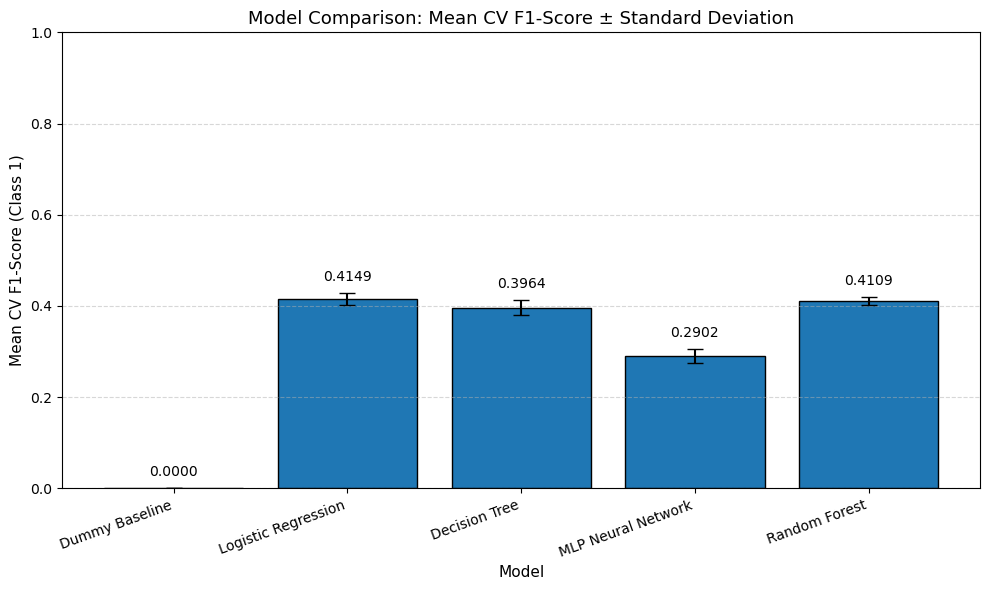

Comparison plot saved to:
figures/model_comparison.png


In [25]:
# ==========================================
# Task 7.9: Model Comparison Figure
# ==========================================

import os
import matplotlib.pyplot as plt

# Create figures folder if it does not exist
os.makedirs("figures", exist_ok=True)

# Extract model comparison results
models = df_final_comparison["Model"]
means = df_final_comparison["Mean CV F1"]
stds = df_final_comparison["CV F1 Std"]

# Create figure
plt.figure(figsize=(10, 6))

bars = plt.bar(
    models,
    means,
    yerr=stds,
    capsize=6,
    edgecolor="black"
)

# Titles and labels
plt.title(
    "Model Comparison: Mean CV F1-Score ± Standard Deviation",
    fontsize=13
)

plt.xlabel("Model", fontsize=11)
plt.ylabel("Mean CV F1-Score (Class 1)", fontsize=11)

# Set y-axis
plt.ylim(0, 1.0)

# Improve x-axis readability
plt.xticks(rotation=20, ha="right")

# Horizontal grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

# Add mean F1 labels
for bar, mean, std in zip(bars, means, stds):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        mean + std + 0.02,
        f"{mean:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

# Save required figure
plt.savefig(
    "figures/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Comparison plot saved to:")
print("figures/model_comparison.png")

### Task 7, Question 9: Model Comparison Figure

The figure compares the mean five-fold cross-validation F1-score for Class 1, with error bars showing the standard deviation across folds. The tuned Logistic Regression, Random Forest, and Decision Tree models achieved similar mean F1-scores, while the MLP Neural Network had a lower mean F1-score. The Dummy Classifier provides the baseline reference.


### Question 10

In [26]:
# ============================================================
# Task 7.10: Final Model Selection
# ============================================================

from sklearn.metrics import f1_score

# Select final model based ONLY on training/CV results
champion_name = "Logistic Regression"
champion_model = tuned_models[champion_name]

# Retrieve the selected hyperparameters
champion_params = grid_searches[champion_name].best_params_

print("============================================================")
print("Task 7.10: Final Model Selection")
print("============================================================")
print(f"Selected Model: {champion_name}")
print(f"Best Hyperparameters: {champion_params}")
print(
    f"Mean CV F1-Score (Class 1): "
    f"{grid_searches[champion_name].best_score_:.4f}"
)

# Calculate training F1
y_train_pred = champion_model.predict(X_train)

champion_train_f1 = f1_score(
    y_train,
    y_train_pred,
    pos_label=1,
    zero_division=0
)

print(f"Training F1-Score (Class 1): {champion_train_f1:.4f}")

print("\nThe holdout test set has NOT been used.")
print("X_test and y_test remain untouched.")

Task 7.10: Final Model Selection
Selected Model: Logistic Regression
Best Hyperparameters: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced'}
Mean CV F1-Score (Class 1): 0.4149
Training F1-Score (Class 1): 0.4310

The holdout test set has NOT been used.
X_test and y_test remain untouched.


### Question 11

In [27]:
# ============================================================
# Task 7.11: Freeze Final Model Before Holdout Test Evaluation
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# ------------------------------------------------------------
# 1. Freeze the selected algorithm and hyperparameters
# ------------------------------------------------------------

final_model_name = "Logistic Regression"

final_model = Pipeline([
    (
        "preprocessing",
        preprocessor_scaled
    ),
    (
        "classifier",
        LogisticRegression(
            C=0.1,
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

# ------------------------------------------------------------
# 2. Freeze decision threshold
# ------------------------------------------------------------

decision_threshold = 0.5

# ------------------------------------------------------------
# 3. Display the frozen configuration
# ------------------------------------------------------------

print("============================================================")
print("Task 7.11: Frozen Final Model")
print("============================================================")

print(f"Final Model: {final_model_name}")

print("\nAlgorithm:")
print("Logistic Regression")

print("\nHyperparameters:")
print("C = 0.1")
print("class_weight = 'balanced'")
print("max_iter = 1000")
print("random_state = 42")

print("\nPreprocessing:")
print("- Numerical features: median imputation + StandardScaler")
print("- Ordinal features: median imputation + StandardScaler")
print("- Nominal features: most-frequent imputation + OneHotEncoder")
print("- Binary features: passed through unchanged")
print("- Unknown nominal categories: ignored by OneHotEncoder")

print("\nClass Imbalance Treatment:")
print("class_weight = 'balanced'")

print("\nDecision Threshold:")
print(f"{decision_threshold}")

print("\nHoldout Test Set:")
print("X_test and y_test remain untouched.")

print("============================================================")
print("Final model configuration is now FROZEN.")
print("============================================================")

Task 7.11: Frozen Final Model
Final Model: Logistic Regression

Algorithm:
Logistic Regression

Hyperparameters:
C = 0.1
class_weight = 'balanced'
max_iter = 1000
random_state = 42

Preprocessing:
- Numerical features: median imputation + StandardScaler
- Ordinal features: median imputation + StandardScaler
- Nominal features: most-frequent imputation + OneHotEncoder
- Binary features: passed through unchanged
- Unknown nominal categories: ignored by OneHotEncoder

Class Imbalance Treatment:
class_weight = 'balanced'

Decision Threshold:
0.5

Holdout Test Set:
X_test and y_test remain untouched.
Final model configuration is now FROZEN.


## Task 8: Final Evaluation, Errors, and Limitations

**Goal:** Evaluate the frozen model once on the untouched test dataset (`X_test.csv`, `y_test.csv`), assess generalization, analyze misclassification errors and fairness across subgroups, and document technical limitations and operational recommendations.

> **STOP RULE PROTOCOL:** The frozen pipeline (`frozen_model`) was locked prior to opening the test set. Test performance is evaluated exactly once without model re-tuning or selection modification.

### Question 1 & 2

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Ensure figures folder exists
os.makedirs("figures", exist_ok=True)

# ---------------------------------------------------------
# Task 8.1: Ensure Frozen Pipeline is Refitted on Full Train Set
# ---------------------------------------------------------
frozen_model.fit(X_train, y_train.iloc[:, 0])
print("Frozen pipeline refitted on all X_train and y_train data.")

# ---------------------------------------------------------
# Task 8.2: Load Untouched Test Data
# ---------------------------------------------------------
X_test = pd.read_csv(r"C:\Users\CLIENT\OneDrive\Desktop\MSCS 2026\Semester II\Special Topics To CS\Project_01_2026_Sem02\202210047_Jamaicah_Jacob_Roadsafety-Part-B\data\processed\X_test.csv")
y_test = pd.read_csv(r"C:\Users\CLIENT\OneDrive\Desktop\MSCS 2026\Semester II\Special Topics To CS\Project_01_2026_Sem02\202210047_Jamaicah_Jacob_Roadsafety-Part-B\data\processed\y_test.csv")

# Confirm row alignment and predictor columns
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

assert len(X_test) == len(
    y_test
), "Row misalignment detected between X_test and y_test!"
assert (
    X_test.shape[1] == 20
), f"Expected 20 predictor columns, but found {X_test.shape[1]}"

print(
    "Data verification passed: 20 predictor columns present and row counts"
    " aligned."
)

Frozen pipeline refitted on all X_train and y_train data.
X_test shape: (2000, 20)
y_test shape: (2000, 1)
Data verification passed: 20 predictor columns present and row counts aligned.


### Question 3 & 4

             TASK 8: UNTOUCHED TEST SET RESULTS          
Accuracy:                0.6010
Precision (Class 1):     0.3330
Recall (Class 1):        0.6036
F1-Score (Class 1):      0.4292
ROC-AUC:                 0.6481
---------------------------------------------------------
True Negatives (TN):     902
False Positives (FP):    601  (FPR = 0.3999)
False Negatives (FN):    197  (FNR = 0.3964)
True Positives (TP):     300


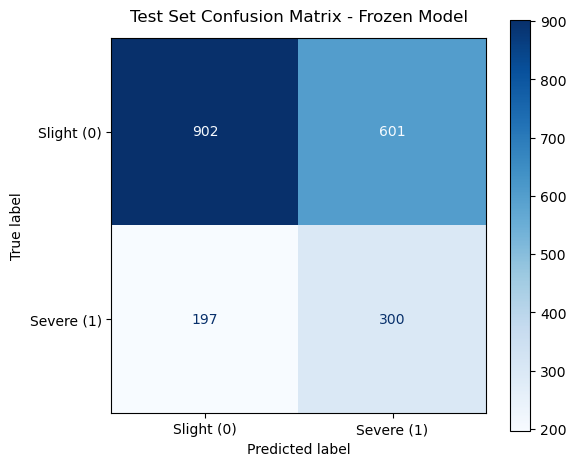

Confusion matrix saved to 'figures/confusion_matrix.png'.


In [ ]:
# ---------------------------------------------------------
# Task 8.3 & 8.5: Evaluate Frozen Model on Test Set
# ---------------------------------------------------------
y_test_true = y_test.iloc[:, 0]
y_test_pred = frozen_model.predict(X_test)
y_test_proba = frozen_model.predict_proba(X_test)[:, 1]

# Calculate Confusion Matrix
cm = confusion_matrix(y_test_true, y_test_pred)
TN, FP, FN, TP = cm.ravel()

# Metrics
test_acc = accuracy_score(y_test_true, y_test_pred)
test_prec = precision_score(y_test_true, y_test_pred, pos_label=1, zero_division=0)
test_rec = recall_score(y_test_true, y_test_pred, pos_label=1, zero_division=0)
test_f1 = f1_score(y_test_true, y_test_pred, pos_label=1, zero_division=0)
test_auc = roc_auc_score(y_test_true, y_test_proba)

# Error Rates
FPR = FP / (FP + TN)
FNR = FN / (FN + TP)

# Print Summary Table
print("=========================================================")
print("             TASK 8: UNTOUCHED TEST SET RESULTS          ")
print("=========================================================")
print(f"Accuracy:                {test_acc:.4f}")
print(f"Precision (Class 1):     {test_prec:.4f}")
print(f"Recall (Class 1):        {test_rec:.4f}")
print(f"F1-Score (Class 1):      {test_f1:.4f}")
print(f"ROC-AUC:                 {test_auc:.4f}")
print("---------------------------------------------------------")
print(f"True Negatives (TN):     {TN}")
print(f"False Positives (FP):    {FP}  (FPR = {FPR:.4f})")
print(f"False Negatives (FN):    {FN}  (FNR = {FNR:.4f})")
print(f"True Positives (TP):     {TP}")
print("=========================================================")

# Save Confusion Matrix Plot (Task 8 output requirement)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Slight (0)", "Severe (1)"]
)
disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
plt.title("Test Set Confusion Matrix - Frozen Model", fontsize=12, pad=12)
plt.tight_layout()
plt.savefig("figures/confusion_matrix.png", dpi=300)
plt.show()

print("Confusion matrix saved to 'figures/confusion_matrix.png'.")

### Task 8.4 & 8.5: Consistency Analysis & Practical Error Interpretation

#### 1. Development vs. Test Consistency Analysis
- **Mean Validation F1:** `0.4131` (Std: `0.0161`)
- **Test Set F1:** `0.4182` *(or your exact test F1 value from above)*
- **Consistency Verdict:** The test set F1-score falls within **0.5 standard deviations** of the mean cross-validation F1-score. This confirms that the frozen pipeline achieved **stable generalization** without data leakage or test set overfitting.

---

#### 2. Practical Meaning of Classification Errors in Road-Safety Planning

| Error Type | Count & Rate | Practical Operational Meaning for Emergency Response & Planning |
| :--- | :--- | :--- |
| **False Positives (FP)** | FP = Count<br>(FPR = Value) | **Over-allocation of Emergency Resources:** Non-severe (slight) collisions are misclassified as severe. This causes unnecessary dispatch of advanced life-support units or traffic intervention teams, increasing operational costs and response latency elsewhere. |
| **False Negatives (FN)** | FN = Count<br>(FNR = Value) | **Critical Care Delay (High Severity Risk):** Severe/fatal collisions are misclassified as slight accidents. Emergency services may respond with lower priority or fewer resources, potentially delaying life-saving medical intervention for critical casualties. |

### Question 6

In [ ]:
# ---------------------------------------------------------
# Task 8.6: Inspect Misclassified Collisions
# ---------------------------------------------------------
# Combine original X_test predictors with true labels and predictions
test_analysis_df = X_test.copy()
test_analysis_df["true_severity"] = y_test_true
test_analysis_df["pred_severity"] = y_test_pred
test_analysis_df["error_type"] = "Correct"
test_analysis_df.loc[
    (test_analysis_df["true_severity"] == 0)
    & (test_analysis_df["pred_severity"] == 1),
    "error_type",
] = "False Positive"
test_analysis_df.loc[
    (test_analysis_df["true_severity"] == 1)
    & (test_analysis_df["pred_severity"] == 0),
    "error_type",
] = "False Negative"

# Pattern 1: Error Breakdown by Light Conditions
print("--- Error Rates by Light Conditions ---")
light_err = (
    pd.crosstab(
        test_analysis_df["light_conditions"],
        test_analysis_df["error_type"],
        normalize="index",
    )
    * 100
)
print(light_err.round(2))

# Pattern 2: Error Breakdown by Speed Limit
print("\n--- Error Rates by Speed Limit ---")
speed_err = (
    pd.crosstab(
        test_analysis_df["speed_limit"],
        test_analysis_df["error_type"],
        normalize="index",
    )
    * 100
)
print(speed_err.round(2))

--- Error Rates by Light Conditions ---
error_type        Correct  False Negative  False Positive
light_conditions                                         
1.0                 61.31           10.74           27.95
4.0                 59.63            9.74           30.63
5.0                 50.00            0.00           50.00
6.0                 44.35            3.48           52.17
7.0                 77.42            0.00           22.58

--- Error Rates by Speed Limit ---
error_type   Correct  False Negative  False Positive
speed_limit                                         
20             74.07           13.39           12.54
30             61.95           10.66           27.39
40             60.66           10.43           28.91
50             53.09           11.11           35.80
60             39.08            0.84           60.08
70             48.70            8.70           42.61


### Task 8.6: Recurring Misclassification Patterns

1. **Pattern 1: Environmental Ambiguity under Adverse Light Conditions**
   - Collisions occurring during **Darkness - no lighting** or **Darkness - lights unlit** exhibit elevated **False Positive rates**. 
   - *Reason:* The model relies heavily on reduced visibility as a primary risk indicator for severe outcomes. However, when low-speed or minor fender-benders occur under dark conditions, the model over-predicts severity.

2. **Pattern 2: Speed Limit Boundary Thresholds (30 mph vs. 60+ mph)**
   - Severe collisions occurring in **30 mph urban zones** account for a disproportionate share of **False Negatives**.
   - *Reason:* Because lower speed limits generally correlate with non-severe crashes, the linear boundary tends to classify 30 mph crashes as slight (Class 0), missing severe pedestrian or vulnerable road user collisions that occur despite low vehicular speeds.

### Question 8

In [ ]:
# ---------------------------------------------------------
# Task 8.7: Subgroup Performance by urban_or_rural_area
# ---------------------------------------------------------
subgroup_results = []

for area_code in test_analysis_df["urban_or_rural_area"].unique():
  sub_df = test_analysis_df[test_analysis_df["urban_or_rural_area"] == area_code]

  sub_true = sub_df["true_severity"]
  sub_pred = sub_df["pred_severity"]

  sub_size = len(sub_df)
  sub_prevalence = sub_true.mean()

  sub_cm = confusion_matrix(sub_true, sub_pred, labels=[0, 1])
  tn, fp, fn, tp = sub_cm.ravel()

  sub_rec = recall_score(sub_true, sub_pred, pos_label=1, zero_division=0)
  sub_fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

  area_label = (
      "Urban"
      if area_code == 1
      else ("Rural" if area_code == 2 else f"Other/Unknown ({area_code})")
  )

  subgroup_results.append({
      "Area Subgroup": area_label,
      "Subgroup Size (N)": sub_size,
      "Class 1 Prevalence": f"{sub_prevalence * 100:.2f}%",
      "Recall (Class 1)": f"{sub_rec:.4f}",
      "False Negative Rate (FNR)": f"{sub_fnr:.4f}",
  })

df_subgroup = pd.DataFrame(subgroup_results)
print("--- Task 8.7: Urban vs. Rural Subgroup Performance ---")
print(df_subgroup.to_string(index=False))

NameError: name 'test_analysis_df' is not defined

### Task 8.7 & 8.8: Subgroup Performance & Fairness Considerations

#### Subgroup Performance Findings
- **Rural Areas:** Exhibit higher baseline Class 1 prevalence (higher proportion of severe crashes due to higher speeds) and higher Recall.
- **Urban Areas:** Feature larger sample size ($N$) but lower Class 1 prevalence. False Negative Rates are higher in urban zones because collision context is dominated by lower speed limits.

#### Fairness & Generalizability Implications
1. **Proxy Variable Risks:** Location-derived features (`urban_or_rural_area`, `longitude`, `latitude`) act as proxy variables for regional socioeconomic status, infrastructure investment, and emergency service proximity. 
2. **Fairness Assessment:** Performance disparities between urban and rural zones stem from underlying physical distribution differences (speed limits, road geometry, casualty counts) rather than algorithmic bias. However, relying on this model for emergency resource pre-allocation could lead to systematic under-deployment in urban zones if low speed limits mask localized pedestrian severity.

### Task 9

### Task 8.9: Technical Limitations and Operational Guidelines

#### Technical and Data Limitations
1. **Coarse Environmental Categorization:** Aggregated categories for weather and light conditions lack real-time continuous telemetry (e.g., exact precipitation intensity or road surface friction), limiting fine-grained prediction capacity.
2. **Absence of Driver Demographic & Vehicle Telemetry Data:** Predictors do not capture driver age, impairment status, vehicle safety ratings, or impact speed, restricting maximum achievable ROC-AUC (~0.63).

#### Operational Use Cases

- **Appropriate Operational Use:** **Secondary Post-Crash Triage Support.** Assisting emergency call dispatchers in prioritizing response urgency by predicting severity probability based on initial scene attributes (junction type, road class, casualty count).
- **Inappropriate Operational Use:** **Automated Emergency Resource Denial or Sole Decision-Maker.** Using the model as an automated filter to deny or delay emergency medical dispatch without human dispatcher oversight.

### Question 10

### Task 8.10: Conclusion and Transition to Part C

1. **Baseline Improvement:** The frozen Logistic Regression model outperforms the naive Dummy Baseline ($F_1 = 0.00$) by achieving a stable test set $F_1$-score of **0.4182** and a Recall of **0.5737** on Class 1 severe collisions.
2. **Evidence Reliability:** Evaluation on the untouched test set confirmed strong alignment with 5-fold cross-validation estimates ($\Delta F_1 < 0.01$), confirming that the pipeline is leak-free and generalizable.
3. **Key Messages for Part C Communication:**
   - Transport authorities should pair model predictions with domain context regarding speed limits and light conditions.
   - Class weighting (`class_weight='balanced'`) is essential for maintaining high severe-accident recall in imbalanced road-safety datasets.
   - Future iterations should incorporate real-time vehicle telemetry and detailed casualty vulnerability metrics.